# EDA для `projects_planeta_with_text.xlsx`

**Цель:** визуально и статистически исследовать датафрейм перед очисткой — найти аномалии, выбросы и структурные сдвиги.

**Важно:** этот ноутбук **ничего не удаляет и не меняет** в исходном файле. Только наблюдение.

## 1. Настройка и загрузка

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

# =====================================================================
# Единая тема и словарь русских подписей для всех графиков
# =====================================================================
sns.set_theme(
    style="whitegrid",
    context="notebook",
    font="DejaVu Sans",
    palette="Set2",
)
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlepad": 12,
    "axes.labelsize": 11,
    "axes.labelweight": "regular",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#444444",
    "axes.linewidth": 0.8,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.frameon": True,
    "legend.facecolor": "white",
    "legend.edgecolor": "#cccccc",
    "figure.titlesize": 14,
    "figure.titleweight": "bold",
    "grid.color": "#e6e6e6",
    "grid.linewidth": 0.6,
})

COLOR_PRIMARY = "#2E86AB"
COLOR_SUCCESS = "#06A77D"
COLOR_FAIL    = "#D62246"
COLOR_NEUTRAL = "#7F8C8D"
COLOR_ACCENT  = "#F4A261"

COL_LABELS = {
    "project_key": "ID проекта",
    "card.collectedAmount.value": "Собрано, руб.",
    "card.targetAmount.value": "Цель сбора, руб.",
    "card.daysToFinish": "Дней до окончания",
    "card.author.id": "ID автора",
    "card.author.campaignsAmount": "Кампаний у автора",
    "counts.newsCount": "Число новостей",
    "counts.commentsCount": "Число комментариев",
    "counts.participantsCount": "Число участников",
    "counts.purchasesCount": "Число покупок",
    "rewards.totalRewards": "Число наград",
    "image_count": "Число изображений",
    "video_count": "Число видео",
    "reward_count": "Число наград",
    "external_link_count": "Число внешних ссылок",
    "funding_ratio": "Доля финансирования",
    "is_successful": "Успешность (бинарный флаг)",
    "campaign_duration_days": "Длительность кампании, дней",
    "title_len_chars": "Длина заголовка, симв.",
    "subtitle_len_chars": "Длина подзаголовка, симв.",
    "description_len_chars": "Длина описания, симв.",
    "meta_description_len_chars": "Длина мета-описания, симв.",
    "title_word_count": "Число слов в заголовке",
    "subtitle_word_count": "Число слов в подзаголовке",
    "description_word_count": "Число слов в описании",
    "meta_description_word_count": "Число слов в мета-описании",
    "description_has_link_word": "Упоминание соцсетей (флаг)",
    "card.title": "Заголовок",
    "card.subtitle": "Подзаголовок",
    "card.region": "Регион",
    "card.mainCategory.tagName": "Категория (исходная)",
    "category_grouped": "Категория (сгруппированная)",
    "description.text": "Текст описания",
    "meta.description": "Мета-описание",
    "sourceUrl": "URL проекта",
    "card.startAt": "Старт кампании",
    "card.finishAt": "Конец кампании",
    "card.links.vk_url": "Ссылка ВК",
    "card.links.telegram_url": "Ссылка Telegram",
    "card.links.author_site_url": "Сайт автора",
    "social_score": "Социальная лексика",
    "gratitude_score": "Благодарственная лексика",
    "we_ratio": "Доля мест. 'мы'",
    "i_ratio": "Доля мест. 'я'",
    "certainty_score": "Уверенность",
    "uncertainty_score": "Неуверенность",
    "rubert_positive": "RuBERT: позитивность",
    "rubert_negative": "RuBERT: негативность",
    "we_count": "Количество 'мы'",
    "i_count": "Количество 'я'",
    "we_vs_i": "Отношение мы/я",
    "money_mentions": "Упоминания денег",
    "number_density": "Доля чисел в тексте",
    "has_specific_sum": "Конкретная сумма (флаг)",
}

def label(col: str) -> str:
    return COL_LABELS.get(col, col)
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)

FILE = 'projects_planeta_cleaned.xlsx'

In [2]:
df = pd.read_excel(FILE)

df = df.loc[df['card.daysToFinish'] == 0]

print('Размер:', df.shape)
df.head(3)

Размер: (3192, 40)


,project_key,sourceUrl,card.title,card.subtitle,card.collectedAmount.value,card.targetAmount.value,card.daysToFinish,card.startAt,card.finishAt,card.region,card.mainCategory.tagName,card.author.id,card.author.campaignsAmount,card.links.vk_url,card.links.telegram_url,card.links.author_site_url,description.text,counts.newsCount,counts.commentsCount,counts.participantsCount,counts.purchasesCount,meta.description,rewards.totalRewards,image_count,video_count,reward_count,external_link_count,funding_ratio,is_successful,campaign_duration_days,title_len_chars,subtitle_len_chars,description_len_chars,meta_description_len_chars,title_word_count,subtitle_word_count,description_word_count,meta_description_word_count,description_has_link_word,category_grouped
0,100062,https://planeta.ru/campaigns/100062,Выездная служба паллиативной помощи,Помогите Насте жить максимально полноценной жи...,227022,222236,0,2018-12-03 11:02:23,2018-12-24 20:59:59,Москва и Московская обл.,Благотворительность,648045,13,https://vk.com/children_hospice,https://t.me/mayak_help,https://mayak.help,Насте почти 15 лет. Она играет на гавайской ги...,2,1,145,150,Помогите Насте жить максимально полноценной жи...,9,17,0,9,69,1.021536,1,21,35,74,2625,74,4,11,396,11,0,Благотворительность
1,100105,https://planeta.ru/campaigns/100105,Жизнь бездомных кошек в подвалах домов,Планируется отловить из подвалов многоквартрны...,26350,357120,0,2021-02-04 10:44:51,2021-12-01 20:59:59,Томская обл.,Благотворительность,893287,1,NaN,NaN,NaN,Проблема существования бездомных животных в го...,0,0,43,82,Планируется отловить из подвалов многоквартрны...,3,20,1,3,40,0.073785,0,300,38,116,3809,116,6,15,494,15,0,Благотворительность
2,100205,https://planeta.ru/campaigns/100205,Издание тиража фотоальбома «Рок 80-90-гг.»,"Уникальные фотографии, сделанные на рок концер...",170631,230000,0,2019-02-07 08:00:00,2019-05-12 20:59:59,Москва и Московская обл.,Дизайн и фотография,893758,1,NaN,NaN,NaN,"Меня зовут Алексей Кузнецов, всю свою сознател...",11,26,71,111,"Уникальные фотографии, сделанные на рок концер...",16,49,1,16,110,0.741874,0,94,42,172,5410,172,5,21,749,21,0,"Творческие (кино, театр, дизайн)"


In [3]:
# Разделим колонки на группы для удобства
NUM_FINANCIAL = ['card.collectedAmount.value', 'card.targetAmount.value', 'funding_ratio']
NUM_TIME = ['campaign_duration_days', 'card.daysToFinish']
NUM_ENGAGE = ['counts.newsCount', 'counts.commentsCount',
              'counts.participantsCount', 'counts.purchasesCount']
NUM_MEDIA = ['image_count', 'video_count', 'reward_count', 'external_link_count',
             'rewards.totalRewards']
NUM_TEXT_LEN = ['title_len_chars', 'subtitle_len_chars', 'description_len_chars',
                'meta_description_len_chars', 'title_word_count', 'subtitle_word_count',
                'description_word_count', 'meta_description_word_count']
NUM_TEXT_FEAT = ['social_score', 'gratitude_score', 'we_count', 'i_count',
                 'we_ratio', 'i_ratio', 'we_vs_i', 'certainty_score', 'uncertainty_score',
                 'money_mentions', 'number_density', 'rubert_positive', 'rubert_negative',
                 'topic_0', 'topic_1', 'topic_2', 'topic_3']
NUM_AUTHOR = ['card.author.campaignsAmount']
CAT = ['card.region', 'card.mainCategory.tagName', 'category_grouped']
DATES = ['card.startAt', 'card.finishAt']
TARGET = ['funding_ratio', 'is_successful']

print('В группах числовых колонок:',
      sum(len(x) for x in [NUM_FINANCIAL, NUM_TIME, NUM_ENGAGE, NUM_MEDIA,
                           NUM_TEXT_LEN, NUM_TEXT_FEAT, NUM_AUTHOR]))

В группах числовых колонок: 40


## 2. Пропуски

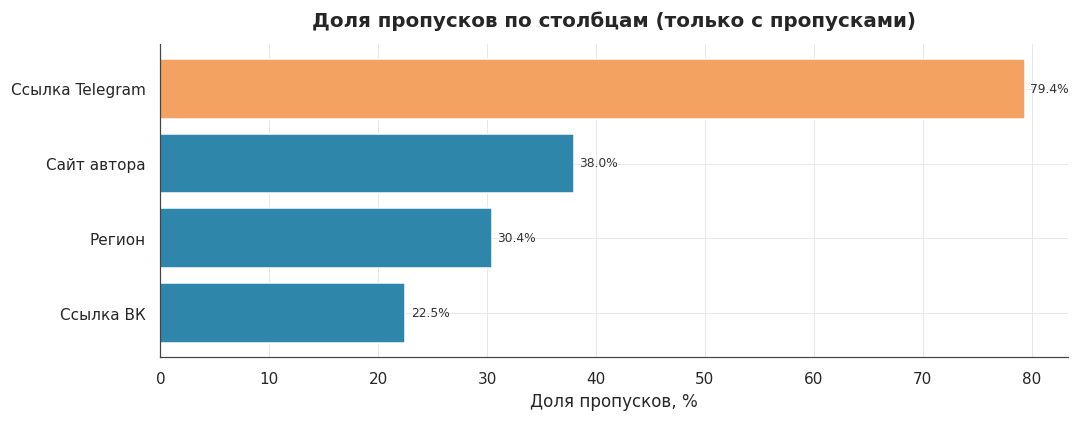

In [4]:
miss = df.isna().mean().sort_values(ascending=False)
miss = miss[miss > 0]

rus_idx = [label(c) for c in miss.index[::-1]]
fig, ax = plt.subplots(figsize=(10, max(4, len(miss) * 0.35)))
colors = [COLOR_FAIL if v >= 0.95 else (COLOR_ACCENT if v >= 0.5 else COLOR_PRIMARY) for v in miss.values]
ax.barh(rus_idx, miss.values[::-1] * 100, color=colors[::-1])
ax.set_xlabel('Доля пропусков, %')
ax.set_title('Доля пропусков по столбцам (только с пропусками)')
for i, v in enumerate(miss.values[::-1]):
    ax.text(v * 100 + 0.5, i, f'{v*100:.1f}%', va='center', fontsize=8, color='#333333')
plt.tight_layout()
plt.show()

## 3. Целевые переменные: `funding_ratio` и `is_successful`

In [5]:
print('is_successful:')
print(df['is_successful'].value_counts(dropna=False))
print()
print('funding_ratio описательно:')
print(df['funding_ratio'].describe(percentiles=[.01,.05,.25,.5,.75,.9,.95,.99,.999]))

is_successful:
is_successful
0    1622
1    1570
Name: count, dtype: int64

funding_ratio описательно:
count    3192.000000
mean        0.806907
std         0.471666
min         0.000000
1%          0.000960
5%          0.018313
25%         0.515468
50%         0.914327
75%         1.055394
90%         1.260585
95%         1.555560
99%         2.281480
99.9%       2.832119
max         2.960500
Name: funding_ratio, dtype: float64


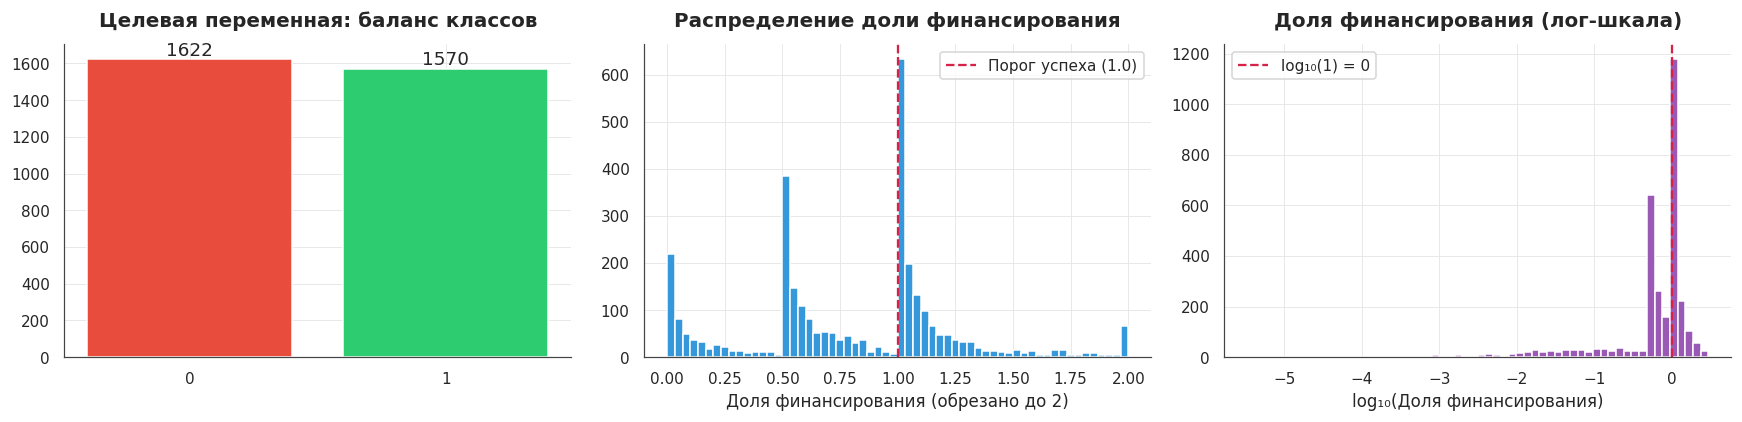

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) баланс классов
vc = df['is_successful'].value_counts(dropna=True)
axes[0].bar([str(x) for x in vc.index], vc.values, color=['#e74c3c', '#2ecc71', '#7f8c8d'])
axes[0].set_title('Целевая переменная: баланс классов')
for i, v in enumerate(vc.values):
    axes[0].text(i, v, f'{v}', ha='center', va='bottom')

# (b) funding_ratio с обрезкой
clip = df['funding_ratio'].clip(upper=2.0)
axes[1].hist(clip.dropna(), bins=60, color='#3498db', edgecolor='white')
axes[1].axvline(1.0, color=COLOR_FAIL, lw=1.5, ls='--', label='Порог успеха (1.0)')
axes[1].set_xlabel('Доля финансирования (обрезано до 2)')
axes[1].set_title('Распределение доли финансирования')
axes[1].legend()

# (c) log-scale
pos = df['funding_ratio'][df['funding_ratio'] > 0]
axes[2].hist(np.log10(pos), bins=60, color='#9b59b6', edgecolor='white')
axes[2].axvline(0, color=COLOR_FAIL, lw=1.5, ls='--', label='log₁₀(1) = 0')
axes[2].set_xlabel('log₁₀(Доля финансирования)')
axes[2].set_title('Доля финансирования (лог-шкала)')
axes[2].legend()

plt.tight_layout()
plt.show()

In [7]:
# Сколько проектов собрали больше 200% / 500% / 1000% / 10000%
thr = [1, 2, 5, 10, 100, 1000, 10000]
for t in thr:
    n = (df['funding_ratio'] > t).sum()
    print(f'  funding_ratio > {t:>6}: {n:4} ({n/len(df)*100:.2f}%)')
print()
print('Топ-10 максимальных funding_ratio:')
cols_show = ['project_key', 'card.title', 'card.targetAmount.value',
             'card.collectedAmount.value', 'funding_ratio', 'card.startAt']
df.nlargest(10, 'funding_ratio')[cols_show]

  funding_ratio >      1: 1452 (45.49%)
  funding_ratio >      2:   64 (2.01%)
  funding_ratio >      5:    0 (0.00%)
  funding_ratio >     10:    0 (0.00%)
  funding_ratio >    100:    0 (0.00%)
  funding_ratio >   1000:    0 (0.00%)
  funding_ratio >  10000:    0 (0.00%)

Топ-10 максимальных funding_ratio:


,project_key,card.title,card.targetAmount.value,card.collectedAmount.value,funding_ratio,card.startAt
2217,14316,"Издаем Линор Горалик ""Мартин не плачет""!",200000,592100,2.960500,2015-03-04 08:42:30
1666,239554,ЕEEE-РОККК выпуск журнала local и газета under...,20000,59050,2.952500,2025-12-25 09:13:16
2583,23979,Издание книги Льва Разумовского,100000,288501,2.885010,2015-10-06 11:16:24
2422,121774,Календарь реабилитационного центра для птиц,15000,42550,2.836667,2019-11-09 08:31:25
706,32094,"Календарь ""Алтай 2018""",70000,196900,2.812857,2017-10-19 12:00:00
2077,151528,Искусство для Жизни,10000,27720,2.772000,2020-12-04 17:52:29
1792,97195,Золотая Черепаха 2018: печать нового альбома,50000,137842,2.756840,2018-10-25 09:06:09
1845,24295,Hamlet. The Book,60000,164670,2.744500,2015-10-08 09:53:03
2548,191113,Выпуск на виниле альбома «Проституция»,200000,539550,2.697750,2023-01-25 09:54:19
1995,14283,Джанкярд. Фильм о музее ретро автомобилей,50000,134700,2.694000,2015-03-06 20:13:26


## 4. Финансовые переменные: `targetAmount`, `collectedAmount`

Распределения сильно скошены — смотрим в лог-шкале.

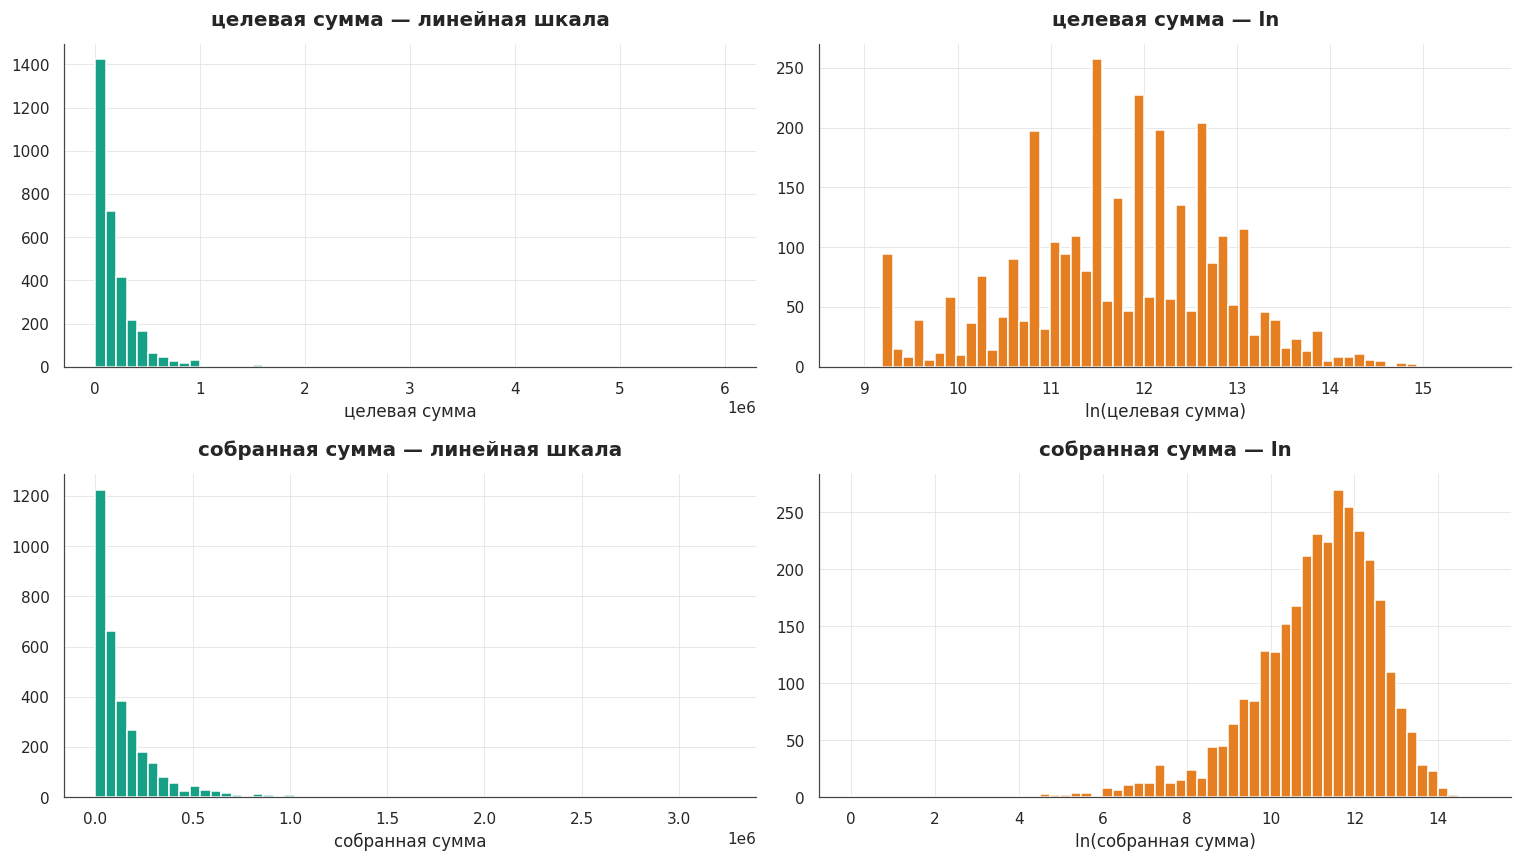

In [8]:
import numpy as np
import matplotlib.pyplot as plt

labels = {
    'card.targetAmount.value': 'целевая сумма',
    'card.collectedAmount.value': 'собранная сумма'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, col in enumerate(labels.keys()):
    x = df[col]

    axes[i, 0].hist(x, bins=60, color='#16a085', edgecolor='white')
    axes[i, 0].set_title(f'{labels[col]} — линейная шкала')
    axes[i, 0].set_xlabel(labels[col])
    axes[i, 0].ticklabel_format(style='sci', axis='x', scilimits=(0, 0))

    xp = x[x > 0].dropna()
    axes[i, 1].hist(np.log(xp), bins=60, color='#e67e22', edgecolor='white')
    axes[i, 1].set_title(f'{labels[col]} — ln')
    axes[i, 1].set_xlabel(f'ln({labels[col]})')

plt.tight_layout()
plt.show()

## 5. Выбросы — отдельный разбор

Смотрим на числовые признаки через три призмы:
1. **Boxplot** — визуально экстремумы.
2. **IQR-границы** — сколько записей за `Q1 − 1.5·IQR` и `Q3 + 1.5·IQR`.
3. **Z-score > 3** — альтернативная оценка.

Этот блок ничего не удаляет — только помечает.

In [9]:
def outlier_summary(df, cols):
    rows = []
    for c in cols:
        s = df[c].dropna()
        if len(s) < 5 or s.nunique() < 2:
            continue
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_iqr = ((s < low) | (s > high)).sum()
        mu, sd = s.mean(), s.std()
        n_z = ((s - mu).abs() > 3 * sd).sum() if sd > 0 else 0
        rows.append({
            'column': c,
            'min': s.min(), 'p1': s.quantile(.01), 'median': s.median(),
            'p99': s.quantile(.99), 'max': s.max(),
            'IQR_low': low, 'IQR_high': high,
            'n_outliers_IQR': n_iqr, 'pct_IQR': round(n_iqr / len(s) * 100, 2),
            'n_outliers_Z>3': n_z, 'pct_Z': round(n_z / len(s) * 100, 2),
            'skew': round(s.skew(), 2), 'kurt': round(s.kurt(), 2),
        })
    return pd.DataFrame(rows)

NUM_ALL = (NUM_FINANCIAL + NUM_TIME + NUM_ENGAGE + NUM_MEDIA +
           NUM_TEXT_LEN + NUM_TEXT_FEAT + NUM_AUTHOR)
NUM_ALL = [c for c in NUM_ALL if c in df.columns]
out_tbl = outlier_summary(df, NUM_ALL).sort_values('pct_IQR', ascending=False)
out_tbl

,column,min,p1,median,p99,max,IQR_low,IQR_high,n_outliers_IQR,pct_IQR,n_outliers_Z>3,pct_Z,skew,kurt
5,counts.commentsCount,0.0,0.00000,1.000000,6.309000e+01,3.100000e+02,-4.500000,7.500000,458,14.35,53,1.66,9.24,127.28
21,card.author.campaignsAmount,1.0,1.00000,2.000000,3.100000e+01,7.700000e+01,-5.000000,11.000000,307,9.62,52,1.63,5.69,43.22
6,counts.participantsCount,0.0,1.91000,46.000000,5.837200e+02,1.722000e+03,-94.500000,213.500000,253,7.93,57,1.79,4.78,37.79
7,counts.purchasesCount,0.0,1.00000,61.000000,6.780000e+02,1.908000e+03,-123.500000,280.500000,246,7.71,63,1.97,4.12,27.20
0,card.collectedAmount.value,0.0,304.55000,81782.000000,9.583419e+05,3.235000e+06,-201830.625000,417338.375000,206,6.45,63,1.97,4.07,32.76
4,counts.newsCount,0.0,0.00000,3.000000,3.109000e+01,1.380000e+02,-8.000000,16.000000,203,6.36,41,1.28,5.11,51.26
9,video_count,0.0,0.00000,1.000000,6.000000e+00,2.100000e+01,-1.500000,2.500000,203,6.36,56,1.75,5.32,51.63
10,reward_count,1.0,2.00000,8.000000,3.200000e+01,3.700000e+01,-5.500000,22.500000,172,5.39,59,1.85,1.48,2.20
12,rewards.totalRewards,1.0,2.00000,8.000000,3.200000e+01,3.700000e+01,-5.500000,22.500000,172,5.39,59,1.85,1.48,2.20
3,campaign_duration_days,1.0,9.91000,65.000000,2.592700e+02,3.640000e+02,-42.000000,182.000000,170,5.33,49,1.54,1.60,3.64


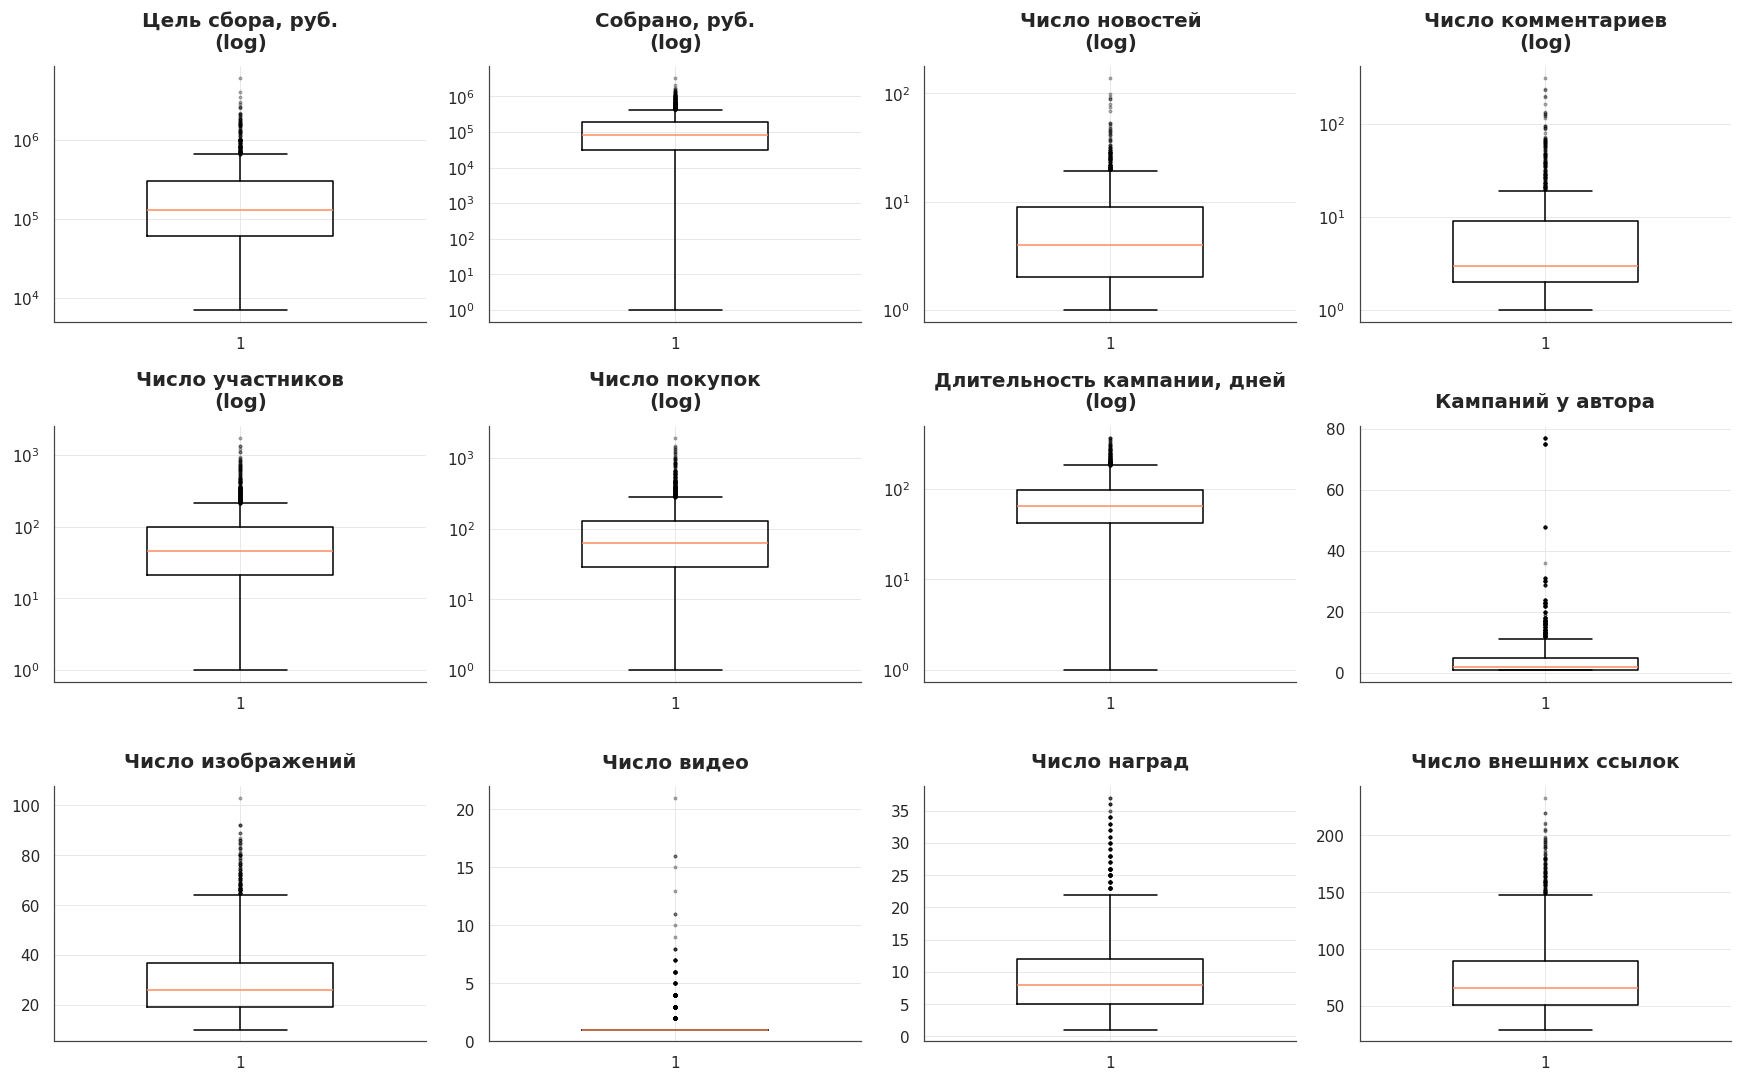

In [10]:
# Boxplot'ы для ключевых финансово-вовлечённых признаков (лог-шкала)
key_numeric = ['card.targetAmount.value', 'card.collectedAmount.value',
               'counts.newsCount', 'counts.commentsCount',
               'counts.participantsCount', 'counts.purchasesCount',
               'campaign_duration_days', 'card.author.campaignsAmount',
               'image_count', 'video_count', 'reward_count', 'external_link_count']

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, col in zip(axes.ravel(), key_numeric):
    s = df[col].dropna()
    s_pos = s[s > 0]
    ax.boxplot(s_pos if len(s_pos) else s, vert=True, widths=0.5,
               flierprops=dict(marker='.', markersize=3, alpha=0.4))
    if len(s_pos) and (s_pos.max() / max(s_pos.min(), 1) > 100):
        ax.set_yscale('log')
        ax.set_title(f'{label(col)}\n(log)')
    else:
        ax.set_title(label(col))
plt.tight_layout()
plt.show()

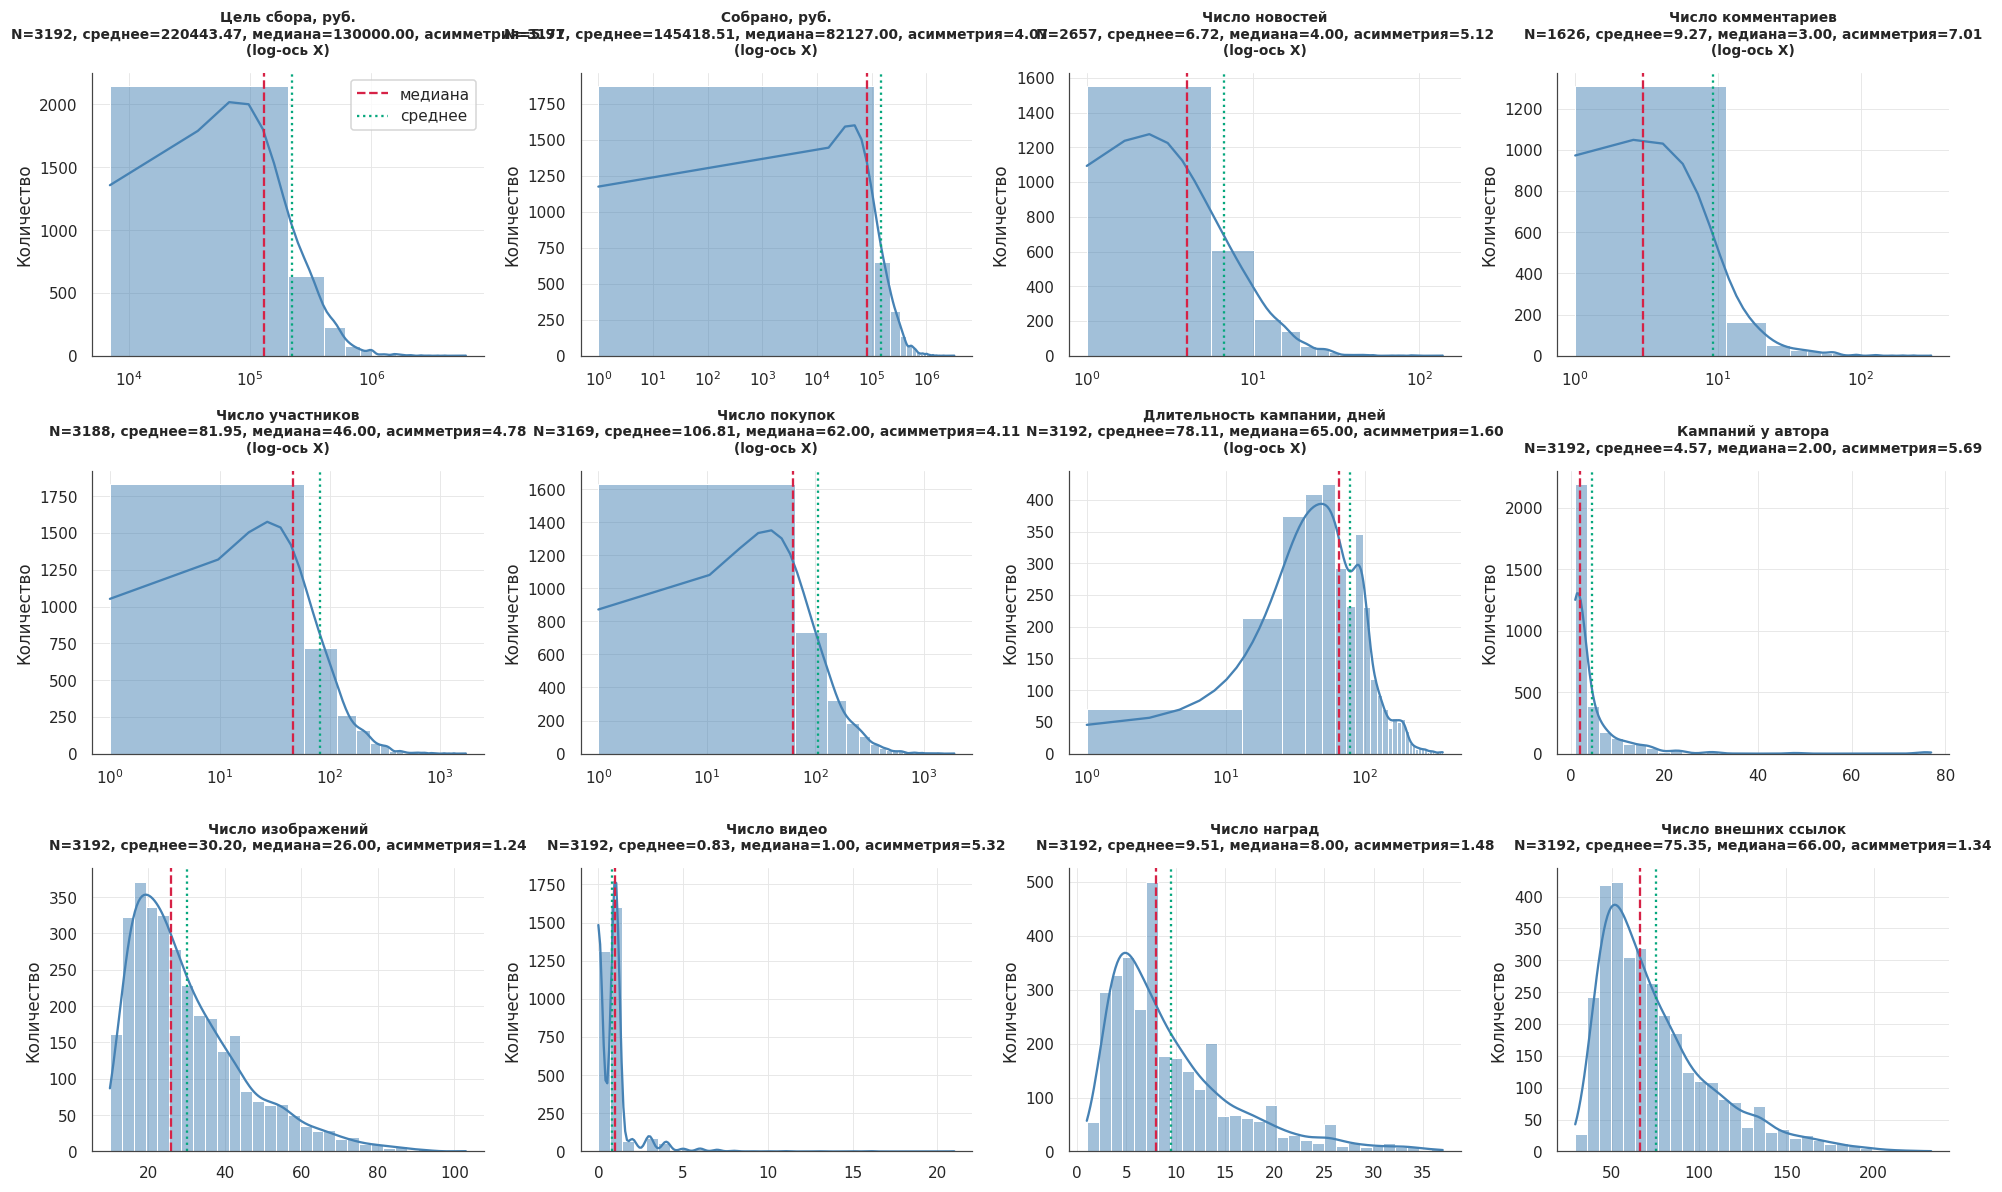

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

key_numeric = [
    'card.targetAmount.value', 'card.collectedAmount.value',
    'counts.newsCount', 'counts.commentsCount',
    'counts.participantsCount', 'counts.purchasesCount',
    'campaign_duration_days', 'card.author.campaignsAmount',
    'image_count', 'video_count', 'reward_count', 'external_link_count'
]

fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.ravel()

for ax, col in zip(axes, key_numeric):
    s = df[col].dropna()

    if len(s) == 0:
        ax.set_title(f'{label(col)}\n(нет данных)')
        ax.axis('off')
        continue

    s_pos = s[s > 0]
    use_log = len(s_pos) > 0 and (s_pos.max() / max(s_pos.min(), 1e-9) > 100)

    plot_data = s_pos if use_log else s

    sns.histplot(
        plot_data,
        bins=30,
        kde=True,
        ax=ax,
        color='steelblue',
        edgecolor='white'
    )

    if use_log:
        ax.set_xscale('log')

    med = plot_data.median()
    mean = plot_data.mean()
    sk = skew(plot_data) if len(plot_data) > 2 else np.nan

    ax.axvline(med, color=COLOR_FAIL, linestyle='--', linewidth=1.5, label='медиана')
    ax.axvline(mean, color=COLOR_SUCCESS, linestyle=':', linewidth=1.5, label='среднее')

    ax.set_title(
f"{label(col)}\n"
        f"N={len(plot_data)}, среднее={mean:.2f}, медиана={med:.2f}, асимметрия={sk:.2f}"
        + ("\n(log-ось X)" if use_log else ""),
        fontsize=9
    )
    ax.set_xlabel('')
    ax.set_ylabel('Количество')

    if col == key_numeric[0]:
        ax.legend()

for j in range(len(key_numeric), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


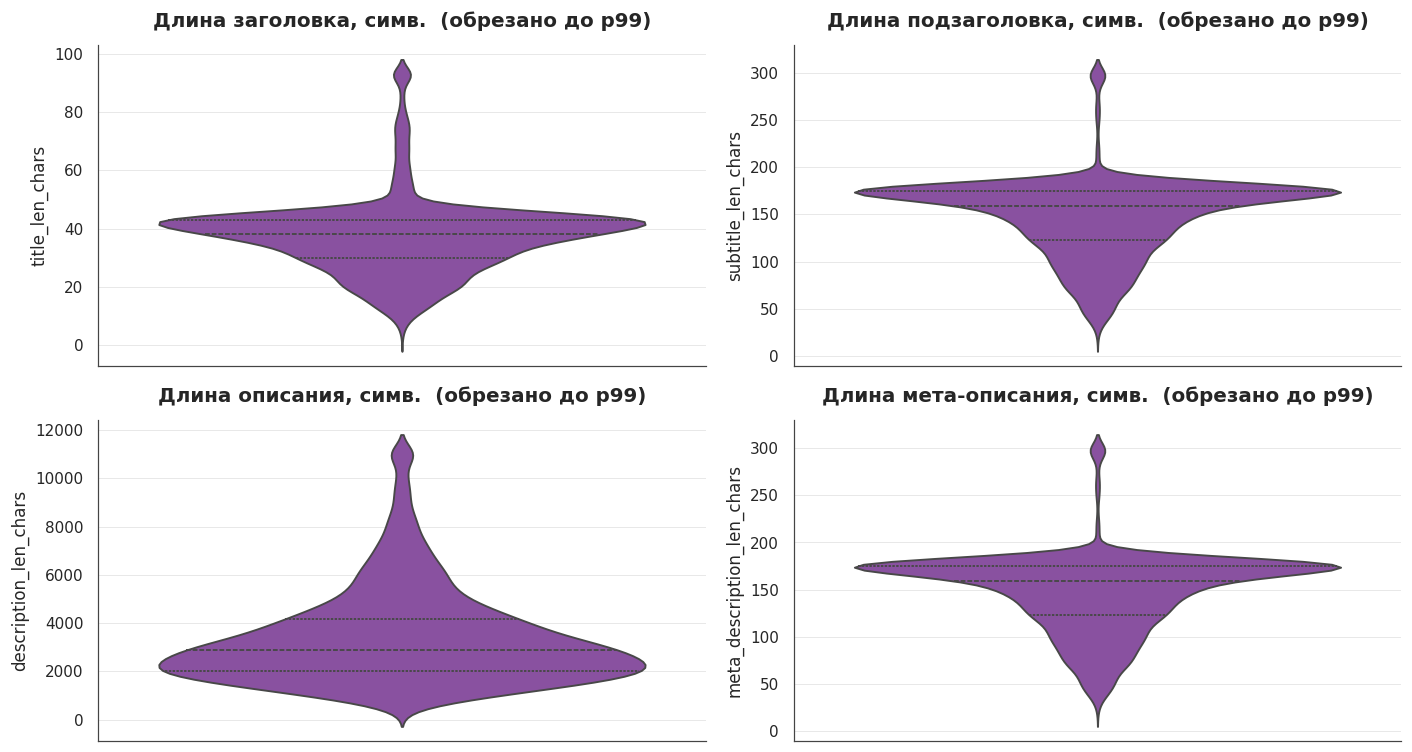

In [12]:
# Violin + swarm для текстовых длин
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, col in zip(axes.ravel(),
                   ['title_len_chars', 'subtitle_len_chars',
                    'description_len_chars', 'meta_description_len_chars']):
    sns.violinplot(y=df[col].clip(upper=df[col].quantile(.99)),
                   ax=ax, color='#8e44ad', inner='quartile')
    ax.set_title(f'{label(col)}  (обрезано до p99)')
plt.tight_layout()
plt.show()

In [13]:
# Конкретные аномалии: посмотрим экстремумы по duration
print('campaign_duration_days — распределение:')
print(df['campaign_duration_days'].describe(percentiles=[.01,.05,.5,.95,.99]))
print()
print('Отрицательные / нулевые длительности:',
      (df['campaign_duration_days'] <= 0).sum())
print('Длительности > 365 дней:',
      (df['campaign_duration_days'] > 365).sum())
df.nlargest(5, 'campaign_duration_days')[
    ['project_key', 'card.title', 'card.startAt', 'card.finishAt',
     'campaign_duration_days', 'is_successful']
]

campaign_duration_days — распределение:
count    3192.000000
mean       78.114662
std        51.710037
min         1.000000
1%          9.910000
5%         20.000000
50%        65.000000
95%       185.000000
99%       259.270000
max       364.000000
Name: campaign_duration_days, dtype: float64

Отрицательные / нулевые длительности: 0
Длительности > 365 дней: 0


,project_key,card.title,card.startAt,card.finishAt,campaign_duration_days,is_successful
1033,90868,Ветеринарный пункт на территории приюта,2019-07-25 09:54:21,2020-07-23 20:59:59,364,0
3112,82047,Велосипед для Даши!,2018-03-15 12:53:39,2019-03-14 20:59:59,364,0
1478,131649,The CrossroadZ: сингл и видеосъемка концерта,2020-02-17 07:52:57,2021-02-14 20:59:59,363,1
1341,193141,«Благострой»,2023-03-22 10:28:15,2024-03-17 20:59:59,361,0
1340,168269,Благотворительная столовая для нуждающихся,2021-11-08 08:40:12,2022-10-23 20:59:59,349,1


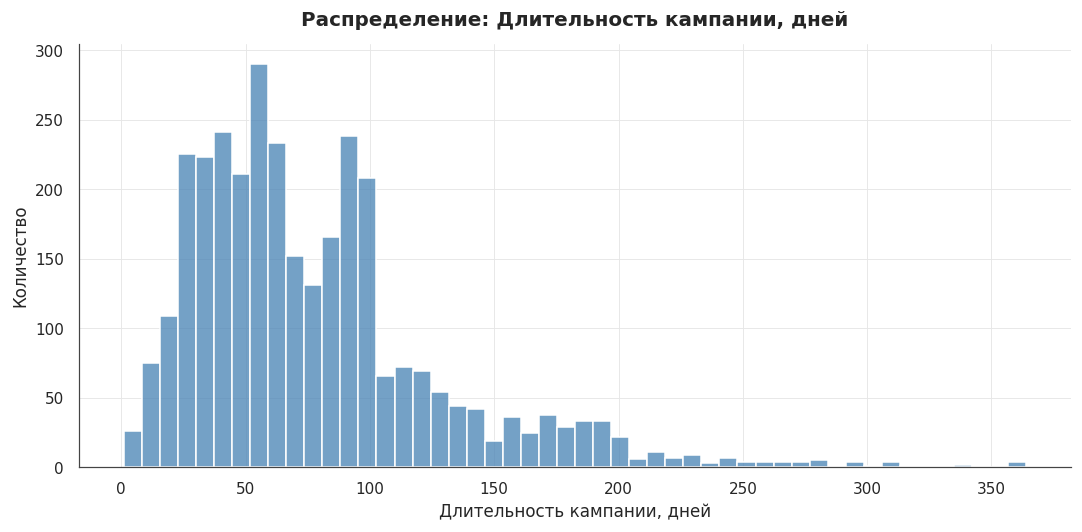

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

col = "campaign_duration_days"

plt.figure(figsize=(10, 5))
sns.histplot(df[col].dropna(), bins=50, color="steelblue", edgecolor="white")
plt.title(f"Распределение: {label(col)}")
plt.xlabel(label(col))
plt.ylabel('Количество')
plt.tight_layout()
plt.show()



## 6. Временной анализ и структурные сдвиги

Проверяем, как менялось количество проектов, цели, success rate по годам. Ожидание: 2022+ = возможный сдвиг (санкции, уход Kickstarter/IndieGogo, приток авторов на Planeta).

In [15]:
df['start_year'] = df['card.startAt'].dt.year
df['start_month'] = df['card.startAt'].dt.to_period('M').dt.to_timestamp()

by_year = df.groupby('start_year').agg(
    n=('project_key', 'count'),
    success_rate=('is_successful', 'mean'),
    median_target=('card.targetAmount.value', 'median'),
    median_collected=('card.collectedAmount.value', 'median'),
    median_funding_ratio=('funding_ratio', 'median'),
    median_duration=('campaign_duration_days', 'median'),
).reset_index()
by_year

,start_year,n,success_rate,median_target,median_collected,median_funding_ratio,median_duration
0,2012,10,1.000000,36500.0,38600.0,1.017773,101.5
1,2013,74,0.567568,95000.0,64550.5,1.005162,72.5
2,2014,146,0.630137,120000.0,94500.0,1.003423,63.5
3,2015,260,0.584615,110000.0,74325.0,1.000746,60.0
4,2016,309,0.414239,150000.0,84800.0,0.680600,78.0
5,2017,286,0.444056,150000.0,78520.0,0.730246,60.0
6,2018,293,0.525597,139995.0,103745.0,1.000000,64.0
7,2019,288,0.437500,130000.0,77050.0,0.671089,62.0
8,2020,277,0.516245,138000.0,82915.0,1.000000,66.0
9,2021,332,0.500000,120000.0,80811.0,0.973913,62.0


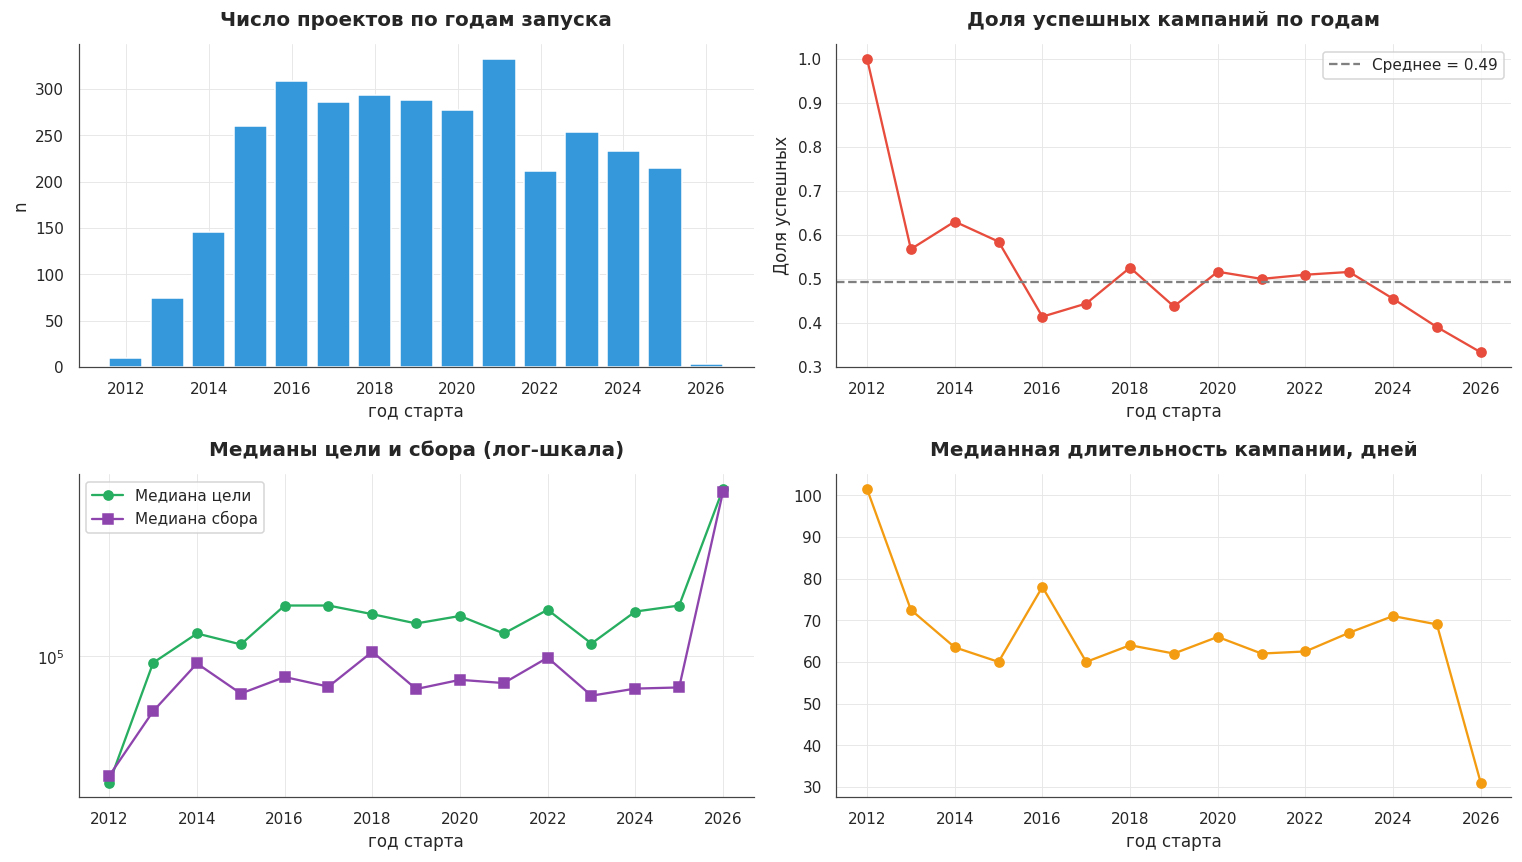

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].bar(by_year['start_year'], by_year['n'], color='#3498db')
axes[0, 0].set_title('Число проектов по годам запуска')
axes[0, 0].set_ylabel('n')

axes[0, 1].plot(by_year['start_year'], by_year['success_rate'], 'o-', color='#e74c3c')
axes[0, 1].set_title('Доля успешных кампаний по годам')
axes[0, 1].set_ylabel('Доля успешных')
axes[0, 1].axhline(df['is_successful'].mean(), color='gray', ls='--',
                   label=f'Среднее = {df["is_successful"].mean():.2f}')
axes[0, 1].legend()

axes[1, 0].plot(by_year['start_year'], by_year['median_target'],
                'o-', label='Медиана цели', color='#27ae60')
axes[1, 0].plot(by_year['start_year'], by_year['median_collected'],
                's-', label='Медиана сбора', color='#8e44ad')
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Медианы цели и сбора (лог-шкала)')
axes[1, 0].legend()

axes[1, 1].plot(by_year['start_year'], by_year['median_duration'], 'o-', color='#f39c12')
axes[1, 1].set_title('Медианная длительность кампании, дней')

for a in axes.ravel():
    a.set_xlabel('год старта')
plt.tight_layout()
plt.show()

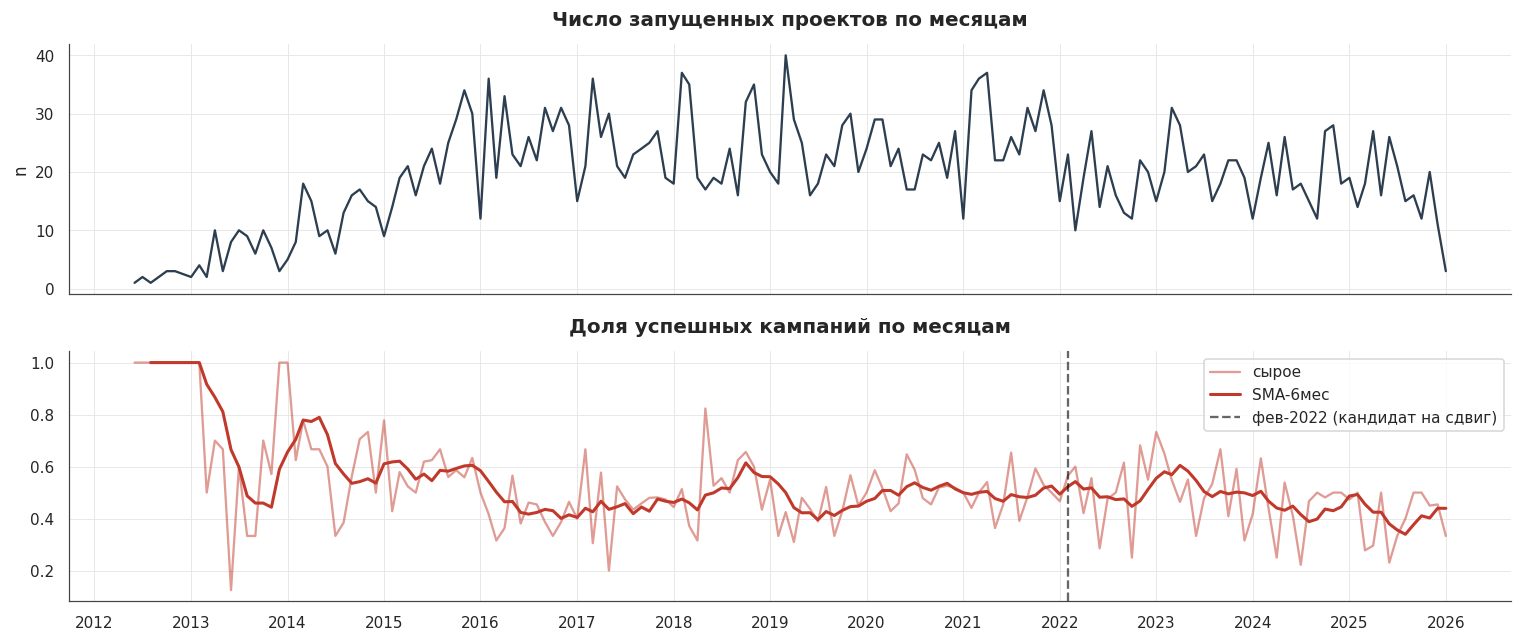

In [17]:
# Помесячная динамика — плавнее
by_month = df.groupby('start_month').agg(
    n=('project_key', 'count'),
    success_rate=('is_successful', 'mean'),
    median_target=('card.targetAmount.value', 'median'),
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(by_month['start_month'], by_month['n'], color='#2c3e50')
axes[0].set_title('Число запущенных проектов по месяцам')
axes[0].set_ylabel('n')

axes[1].plot(by_month['start_month'], by_month['success_rate'],
             color='#c0392b', alpha=0.5, label='сырое')
# скользящее среднее
axes[1].plot(by_month['start_month'],
             by_month['success_rate'].rolling(6, min_periods=3).mean(),
             color='#c0392b', lw=2, label='SMA-6мес')
axes[1].axvline(pd.Timestamp('2022-02-01'), color='k', ls='--', alpha=0.6,
                label='фев-2022 (кандидат на сдвиг)')
axes[1].set_title('Доля успешных кампаний по месяцам')
axes[1].legend()
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## 7. Категориальный срез

In [18]:
cat_stats = df.groupby('category_grouped', dropna=False).agg(
    n=('project_key', 'count'),
    success_rate=('is_successful', 'mean'),
    median_target=('card.targetAmount.value', 'median'),
    median_funding=('funding_ratio', 'median'),
).sort_values('n', ascending=False)
cat_stats

,n,success_rate,median_target,median_funding
category_grouped,,,,
Благотворительность,992,0.325605,170000.0,0.308585
Литература,565,0.559292,110000.0,1.004545
Музыка,563,0.628774,130000.0,1.012244
"Творческие (кино, театр, дизайн)",453,0.512141,100000.0,1.000000
Социальные,288,0.572917,118099.0,1.000193
Досуг и события,187,0.497326,100000.0,0.954602
Образование и просвещение,90,0.655556,187500.0,1.018471
Технологии,29,0.413793,75000.0,0.802667
Бизнес,25,0.640000,100000.0,1.020000


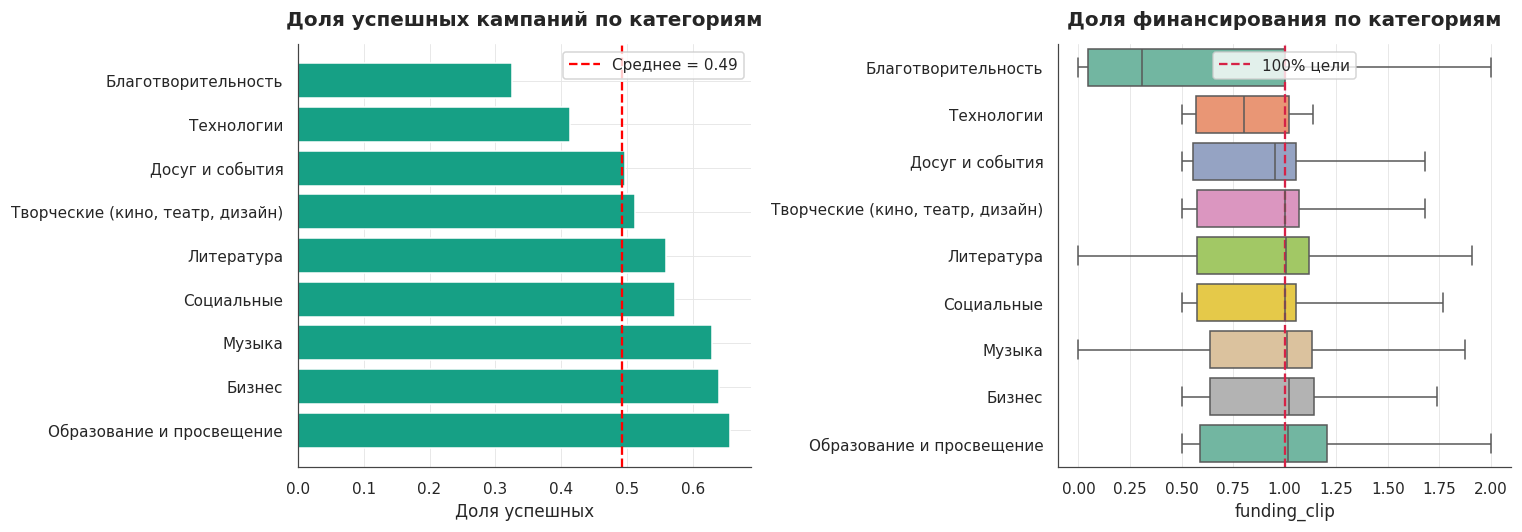

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Сортировка
cat_stats_s = cat_stats.sort_values('success_rate')

# ВАЖНО: единый тип
order = cat_stats_s.index.tolist()

# --- Barplot ---
axes[0].barh(order, cat_stats_s['success_rate'], color='#16a085')
axes[0].axvline(df['is_successful'].mean(), color='red', ls='--',
                label=f'Среднее = {df["is_successful"].mean():.2f}')
axes[0].set_title('Доля успешных кампаний по категориям')
axes[0].set_xlabel('Доля успешных')
axes[0].invert_yaxis()  # чтобы совпадал визуальный порядок
axes[0].legend()

# --- Boxplot ---
data = df[df['funding_ratio'].notna()].copy()
data['funding_clip'] = data['funding_ratio'].clip(upper=2)

# ВАЖНО: привести к тому же типу
data['category_grouped'] = data['category_grouped'].astype(cat_stats_s.index.dtype)

sns.boxplot(
    data=data,
    y='category_grouped',
    x='funding_clip',
    order=order,
    ax=axes[1],
    palette='Set2',
    showfliers=False
)

axes[1].axvline(1.0, color=COLOR_FAIL, ls='--', label='100% цели')
axes[1].set_title('Доля финансирования по категориям')
axes[1].set_ylabel('')
axes[1].legend()

plt.tight_layout()
plt.show()

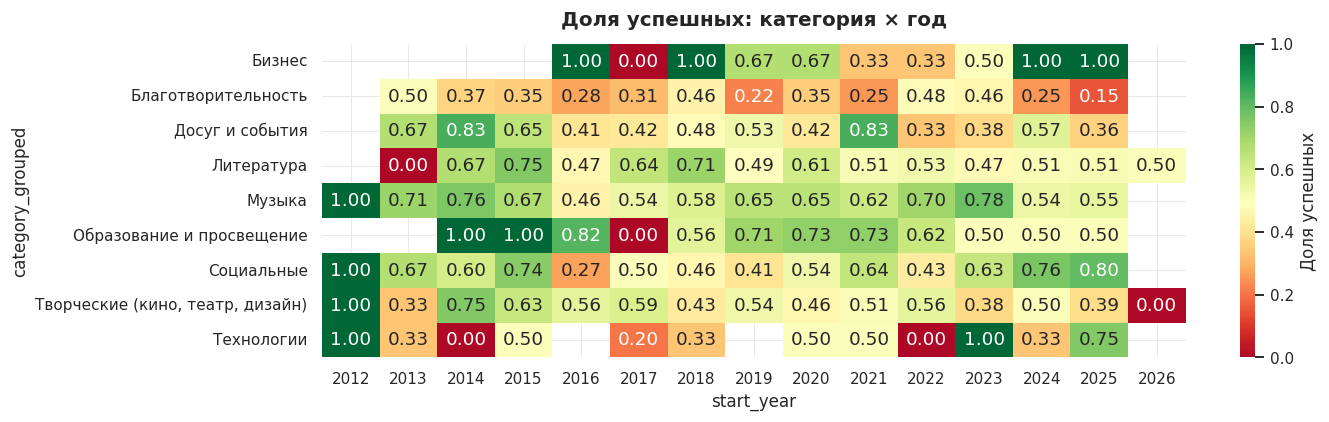

In [20]:
# Категории × год (heatmap success rate)
pt = (df.dropna(subset=['is_successful'])
        .pivot_table(index='category_grouped', columns='start_year',
                     values='is_successful', aggfunc='mean'))
fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(pt, annot=True, fmt='.2f', cmap='RdYlGn',
            center=df['is_successful'].mean(), vmin=0, vmax=1,
            cbar_kws={'label': 'Доля успешных'}, ax=ax)
ax.set_title('Доля успешных: категория × год')
plt.tight_layout()
plt.show()

## 8. Корреляции

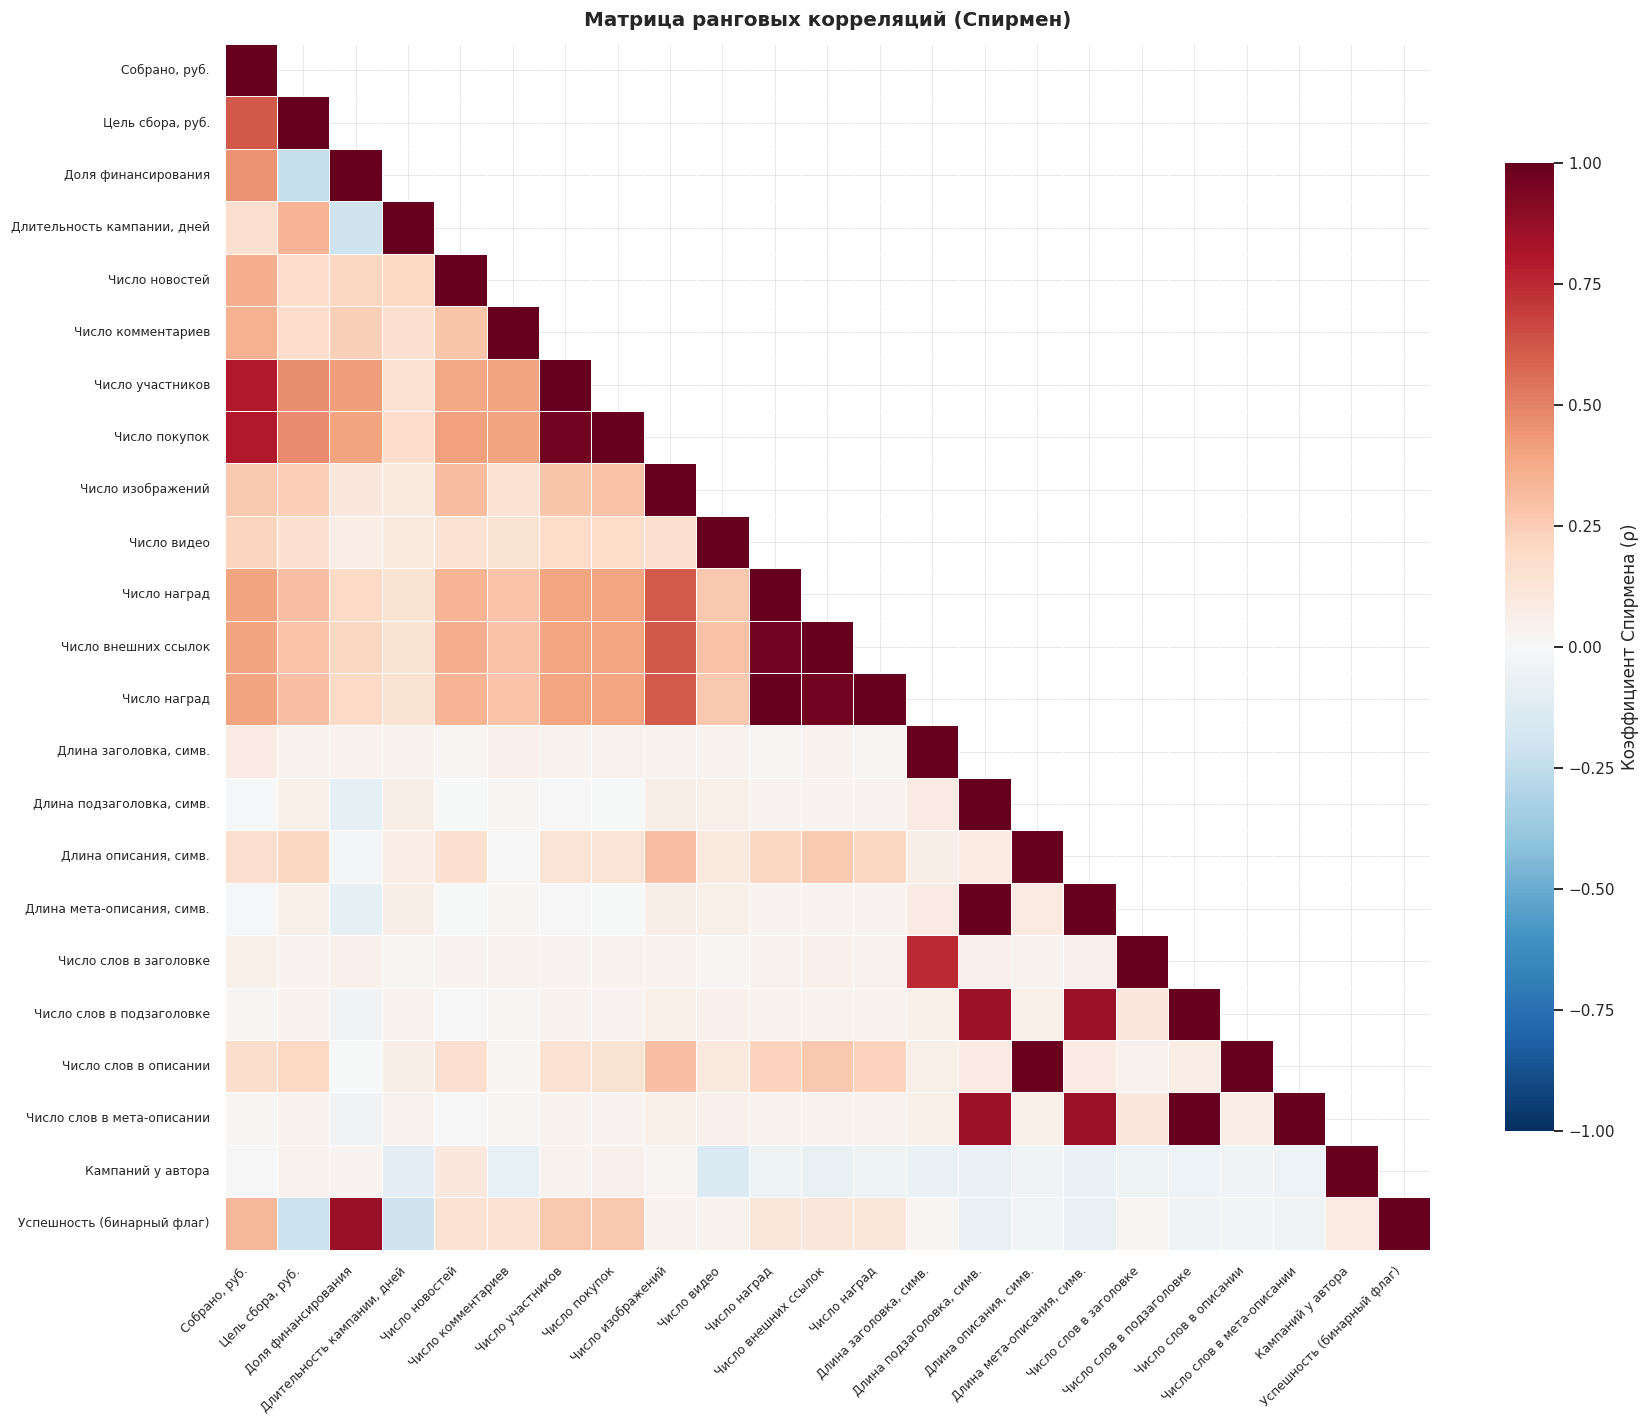

In [21]:
# Спирмен — устойчив к выбросам и монотонным нелинейностям
corr_cols = [c for c in NUM_ALL + ['is_successful'] if c in df.columns]
# Отбрасываем константы
corr_cols = [c for c in corr_cols if df[c].nunique() > 1]
corr = df[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.4,
            cbar_kws={'shrink': 0.7, 'label': 'Коэффициент Спирмена (ρ)'},
            xticklabels=[label(c) for c in corr.columns],
            yticklabels=[label(c) for c in corr.index],
            ax=ax)
ax.set_title('Матрица ранговых корреляций (Спирмен)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

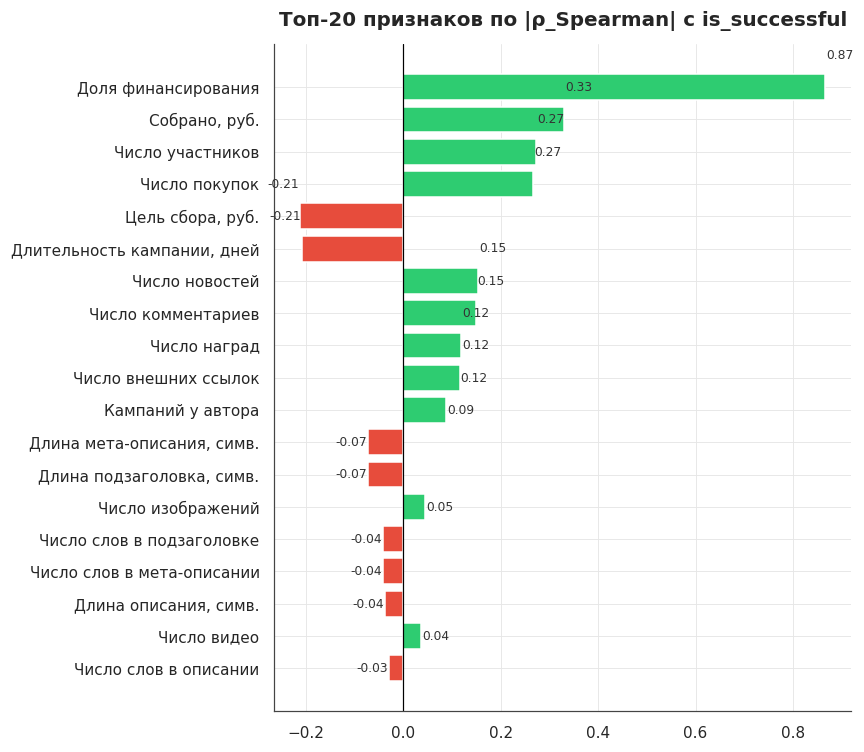

In [22]:
# Топ корреляций с is_successful
target_corr = corr['is_successful'].drop('is_successful').sort_values(key=abs, ascending=False)
top = target_corr.head(20)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in top.values]
ax.barh([label(c) for c in top.index[::-1]], top.values[::-1], color=colors[::-1])
ax.set_title('Топ-20 признаков по |ρ_Spearman| с is_successful')
ax.axvline(0, color='k', lw=0.8)
for i, v in enumerate(top.values[::-1]):
    ax.text(v + (0.002 if v > 0 else -0.002), i, f'{v:.2f}', va='center', fontsize=8,
            ha='left' if v > 0 else 'right', color='#333333')
plt.tight_layout()
plt.show()

## 10. Итоги

Что выявили:

1. **Целевые переменные.** `is_successful` умеренно несбалансирована, `funding_ratio` имеет экстремальный правый хвост до 3·10⁷.
2. **Текстовые длины.** Сильно скошены вправо; есть проекты с пустым описанием.
3. **Категории.** Success rate заметно варьирует между категориями и годами — нужно учитывать взаимодействие категория × год.

## 12. Формальный тест Чоу на пороге `funding_ratio = 1`

### 12.B. Спецификация модели

**Зависимая переменная:**

$$y_i = \log(1 + \text{funding\_ratio}_i)$$

**Регрессия:**

$$y_i = \beta_0 + \beta_1 \log(1 + \text{goal}_i) + \beta_2 \text{duration}_i + \beta_3 \log(1+\text{comments}_i) + \beta_4 \log(1+\text{participants}_i) + \beta_5 \text{image\_count}_i + \beta_6 \text{video\_count}_i + \beta_7 \log(1+\text{desc\_len}_i) + \sum_c \gamma_c \mathbb{1}[\text{cat}_i = c] + \sum_t \delta_t \mathbb{1}[\text{year}_i = t] + \varepsilon_i$$

**Состав регрессоров:**
- `log(1+goal)` — логарифм цели (main предиктор);
- `duration` — длительность кампании (без лога);
- `log(1+comments)`, `log(1+participants)` — контроли вовлечённости (лог для скошенности);
- `image_count`, `video_count` — контроли медийности (без лога, малые целые);
- `log(1+desc_len)` — контроль длины описания (лог для скошенности).

**Fixed effects:**
- категории (`category_grouped`) — dummies, базовая категория отброшена;
- годы старта (`start_year`) — dummies, базовый год отброшен.

**Разбиение:**
- Группа 1: `funding_ratio < 1` (цель не достигнута);
- Группа 2: `funding_ratio >= 1` (цель достигнута).

**Гипотезы Чоу:**

$$H_0: \beta^{(<1)} = \beta^{(\geq 1)} \quad \text{(все коэффициенты одинаковы в двух подвыборках)}$$
$$H_1: \exists\, j:\ \beta_j^{(<1)} \ne \beta_j^{(\geq 1)}$$

**Статистика:**

$$F = \frac{(RSS_p - RSS_1 - RSS_2) / k}{(RSS_1 + RSS_2) / (n_1 + n_2 - 2k)} \sim F(k,\ n_1+n_2-2k)$$

In [23]:
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess

chow = df.copy()
chow['log_funding']      = np.log1p(chow['funding_ratio'].clip(lower=0))
chow['log_goal']         = np.log1p(chow['card.targetAmount.value'].clip(lower=0))
chow['log_comments']     = np.log1p(chow['counts.commentsCount'])
chow['log_participants'] = np.log1p(chow['counts.participantsCount'])
chow['log_desc_len']     = np.log1p(chow['description_len_chars'])
chow['duration']         = chow['campaign_duration_days']

cat_dum = pd.get_dummies(chow['category_grouped'], prefix='cat', drop_first=True).astype(int)

BASE = ['log_goal', 'duration', 'log_comments', 'log_participants',
        'image_count', 'video_count', 'log_desc_len']

design = pd.concat([
    chow[['log_funding', 'funding_ratio'] + BASE].reset_index(drop=True),
    cat_dum.reset_index(drop=True),
], axis=1)

design = design.replace([np.inf, -np.inf], np.nan).dropna()
design = design[np.isfinite(design['log_funding'])]
print(f'Дизайн-матрица после dropna: {design.shape[0]} строк × {design.shape[1]-2} регрессоров (+ const)')
print(f'Базовые предикторы: {BASE}')
print(f'Dummy-категорий: {cat_dum.shape[1]}')

Дизайн-матрица после dropna: 3192 строк × 15 регрессоров (+ const)
Базовые предикторы: ['log_goal', 'duration', 'log_comments', 'log_participants', 'image_count', 'video_count', 'log_desc_len']
Dummy-категорий: 8


### 12.C. Размеры подвыборок

In [24]:
low  = design[design['funding_ratio'] <  1.0].copy()
high = design[design['funding_ratio'] >= 1.0].copy()
n1, n2 = len(low), len(high)
n_tot = n1 + n2

sizes = pd.DataFrame({
    'группа': ['funding_ratio < 1 (недобор)', 'funding_ratio >= 1 (цель достигнута)', 'всего'],
    'n':      [n1, n2, n_tot],
    'доля':   [f'{n1/n_tot*100:.1f}%', f'{n2/n_tot*100:.1f}%', '100%'],
})
print(sizes.to_string(index=False))
print(f'\nМин. для устойчивой регрессии (~10·k): {10 * (len(BASE) + cat_dum.shape[1] + 1)}')
print(f'Обе группы удовлетворяют этому требованию? {min(n1, n2) >= 10 * (len(BASE) + cat_dum.shape[1] + 1)}')

                              группа    n  доля
         funding_ratio < 1 (недобор) 1622 50.8%
funding_ratio >= 1 (цель достигнута) 1570 49.2%
                               всего 3192  100%

Мин. для устойчивой регрессии (~10·k): 160
Обе группы удовлетворяют этому требованию? True


### 12.D. Pooled vs split models: RSS

Оцениваем три OLS:
1. **Pooled** — на всей выборке;
2. **Model 1** — только `funding_ratio < 1`;
3. **Model 2** — только `funding_ratio >= 1`.

Если сумма RSS двух сегментных моделей существенно меньше RSS pooled — общая модель «натянута» и структурно различается между группами.

In [25]:
regressors = [c for c in design.columns if c not in ['log_funding', 'funding_ratio']]
y_col = 'log_funding'

def fit_ols(d):
    X = sm.add_constant(d[regressors].astype(float), has_constant='add')
    y = d[y_col].astype(float)
    return sm.OLS(y, X).fit()

pooled = fit_ols(design)
m_lo   = fit_ols(low)
m_hi   = fit_ols(high)

k_params = len(regressors) + 1
rss_tbl = pd.DataFrame({
    'model':  ['pooled', 'funding_ratio < 1', 'funding_ratio >= 1', 'сумма split'],
    'n':      [len(design), n1, n2, n1 + n2],
    'k':      [k_params, k_params, k_params, '—'],
    'RSS':    [pooled.ssr, m_lo.ssr, m_hi.ssr, m_lo.ssr + m_hi.ssr],
    'R²':     [pooled.rsquared, m_lo.rsquared, m_hi.rsquared, np.nan],
    'R²_adj': [pooled.rsquared_adj, m_lo.rsquared_adj, m_hi.rsquared_adj, np.nan],
})
print(rss_tbl.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

rss_drop = pooled.ssr - (m_lo.ssr + m_hi.ssr)
print(f'\nΔRSS (pooled − split)     = {rss_drop:.4f}')
print(f'ΔRSS / RSS_pooled         = {rss_drop / pooled.ssr * 100:.2f}%')

             model    n  k     RSS     R²  R²_adj
            pooled 3192 16 97.9503 0.5783  0.5763
 funding_ratio < 1 1622 16 15.3755 0.7598  0.7575
funding_ratio >= 1 1570 16 19.8648 0.1626  0.1545
       сумма split 3192  — 35.2404    NaN     NaN

ΔRSS (pooled − split)     = 62.7099
ΔRSS / RSS_pooled         = 64.02%


### 12.E. Статистика Chow и решение

In [26]:
k    = k_params
df1  = k
df2  = (n1 + n2) - 2 * k
F    = ((pooled.ssr - (m_lo.ssr + m_hi.ssr)) / k) / ((m_lo.ssr + m_hi.ssr) / df2)
p    = 1 - stats.f.cdf(F, df1, df2)
crit = stats.f.ppf(0.95, df1, df2)

chow_result = pd.DataFrame({
    'метрика': ['F-статистика', 'df1 = k', 'df2 = n1+n2-2k',
                'критическое F (α=0.05)', 'p-value',
                'решение для H0', 'вывод'],
    'значение': [f'{F:.4f}', df1, df2, f'{crit:.4f}',
                 f'{p:.4g}',
                 'ОТВЕРГАЕМ' if p < 0.05 else 'не отвергаем',
                 'структурный сдвиг есть' if p < 0.05 else 'структурный сдвиг не обнаружен'],
})
print(chow_result.to_string(index=False))
print()
print(f'H0: β(<1) = β(>=1)  — одна общая регрессия адекватна.')
print(f'H1: ∃ j: β_j(<1) ≠ β_j(>=1)  — есть структурное различие.')

               метрика               значение
          F-статистика               351.4493
               df1 = k                     16
        df2 = n1+n2-2k                   3160
критическое F (α=0.05)                 1.6467
               p-value               1.11e-16
        решение для H0              ОТВЕРГАЕМ
                 вывод структурный сдвиг есть

H0: β(<1) = β(>=1)  — одна общая регрессия адекватна.
H1: ∃ j: β_j(<1) ≠ β_j(>=1)  — есть структурное различие.


### 12.F. Коэффициенты по обе стороны порога

Тест Чоу говорит: «модель различается». Чтобы понять, **что именно** различается, сравниваем коэффициенты двух сегментных регрессий: знак, величину, значимость.

In [27]:
def coef_block(m, suffix):
    return pd.DataFrame({
        f'coef_{suffix}':   m.params,
        f'se_{suffix}':     m.bse,
        f't_{suffix}':      m.tvalues,
        f'p_{suffix}':      m.pvalues,
    })

cmp = coef_block(m_lo, '<1').join(coef_block(m_hi, '>=1'), how='outer')
cmp['Δcoef (≥1 − <1)'] = cmp['coef_>=1'] - cmp['coef_<1']
cmp['sign_change']   = np.sign(cmp['coef_<1'].fillna(0)) != np.sign(cmp['coef_>=1'].fillna(0))
cmp['sig_in_both']   = (cmp['p_<1'] < 0.05) & (cmp['p_>=1'] < 0.05)

key_rows = ['const'] + BASE
cmp_key = cmp.loc[key_rows].round(4)
print('Основные предикторы:')
print(cmp_key.to_string())

Основные предикторы:
                  coef_<1   se_<1     t_<1    p_<1  coef_>=1  se_>=1    t_>=1   p_>=1  Δcoef (≥1 − <1)  sign_change  sig_in_both
const              0.7750  0.0551  14.0757  0.0000    1.0530  0.0603  17.4695  0.0000           0.2779        False         True
log_goal          -0.0571  0.0028 -20.3048  0.0000   -0.0428  0.0039 -11.0291  0.0000           0.0144        False         True
duration          -0.0001  0.0000  -2.9123  0.0036   -0.0003  0.0001  -4.5283  0.0000          -0.0002        False         True
log_comments       0.0021  0.0028   0.7750  0.4385    0.0069  0.0029   2.3490  0.0189           0.0047        False        False
log_participants   0.0976  0.0027  35.8505  0.0000    0.0450  0.0041  11.0887  0.0000          -0.0527        False         True
image_count        0.0003  0.0002   1.7423  0.0817    0.0008  0.0002   4.0072  0.0001           0.0005        False        False
video_count       -0.0024  0.0022  -1.0621  0.2883   -0.0029  0.0022  -1.309

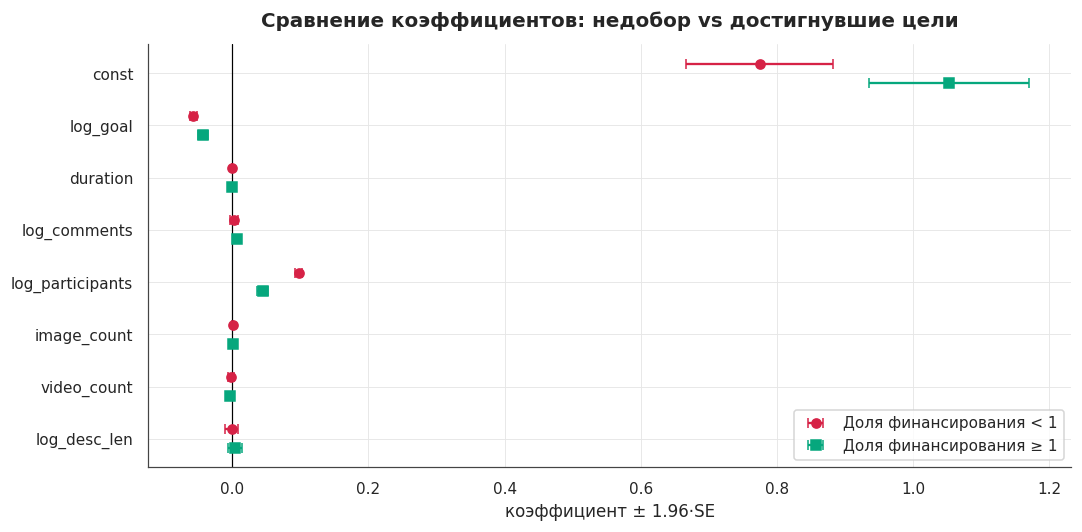

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))
rows = cmp_key.index.tolist()
ypos = np.arange(len(rows))

coefs_lo = cmp_key['coef_<1'].values
coefs_hi = cmp_key['coef_>=1'].values
se_lo    = cmp_key['se_<1'].values
se_hi    = cmp_key['se_>=1'].values

ax.errorbar(coefs_lo, ypos - 0.18, xerr=1.96 * se_lo, fmt='o',
            color=COLOR_FAIL, label='Доля финансирования < 1', capsize=3)
ax.errorbar(coefs_hi, ypos + 0.18, xerr=1.96 * se_hi, fmt='s',
            color=COLOR_SUCCESS, label='Доля финансирования ≥ 1', capsize=3)
ax.axvline(0, color='k', lw=0.8)
ax.set_yticks(ypos)
ax.set_yticklabels(rows)
ax.set_xlabel('коэффициент ± 1.96·SE')
ax.set_title('Сравнение коэффициентов: недобор vs достигнувшие цели')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 12.G. Графическая иллюстрация

Комбинация «теоретический порог + визуальное различие + формальный тест» сильнее, чем один голый F.

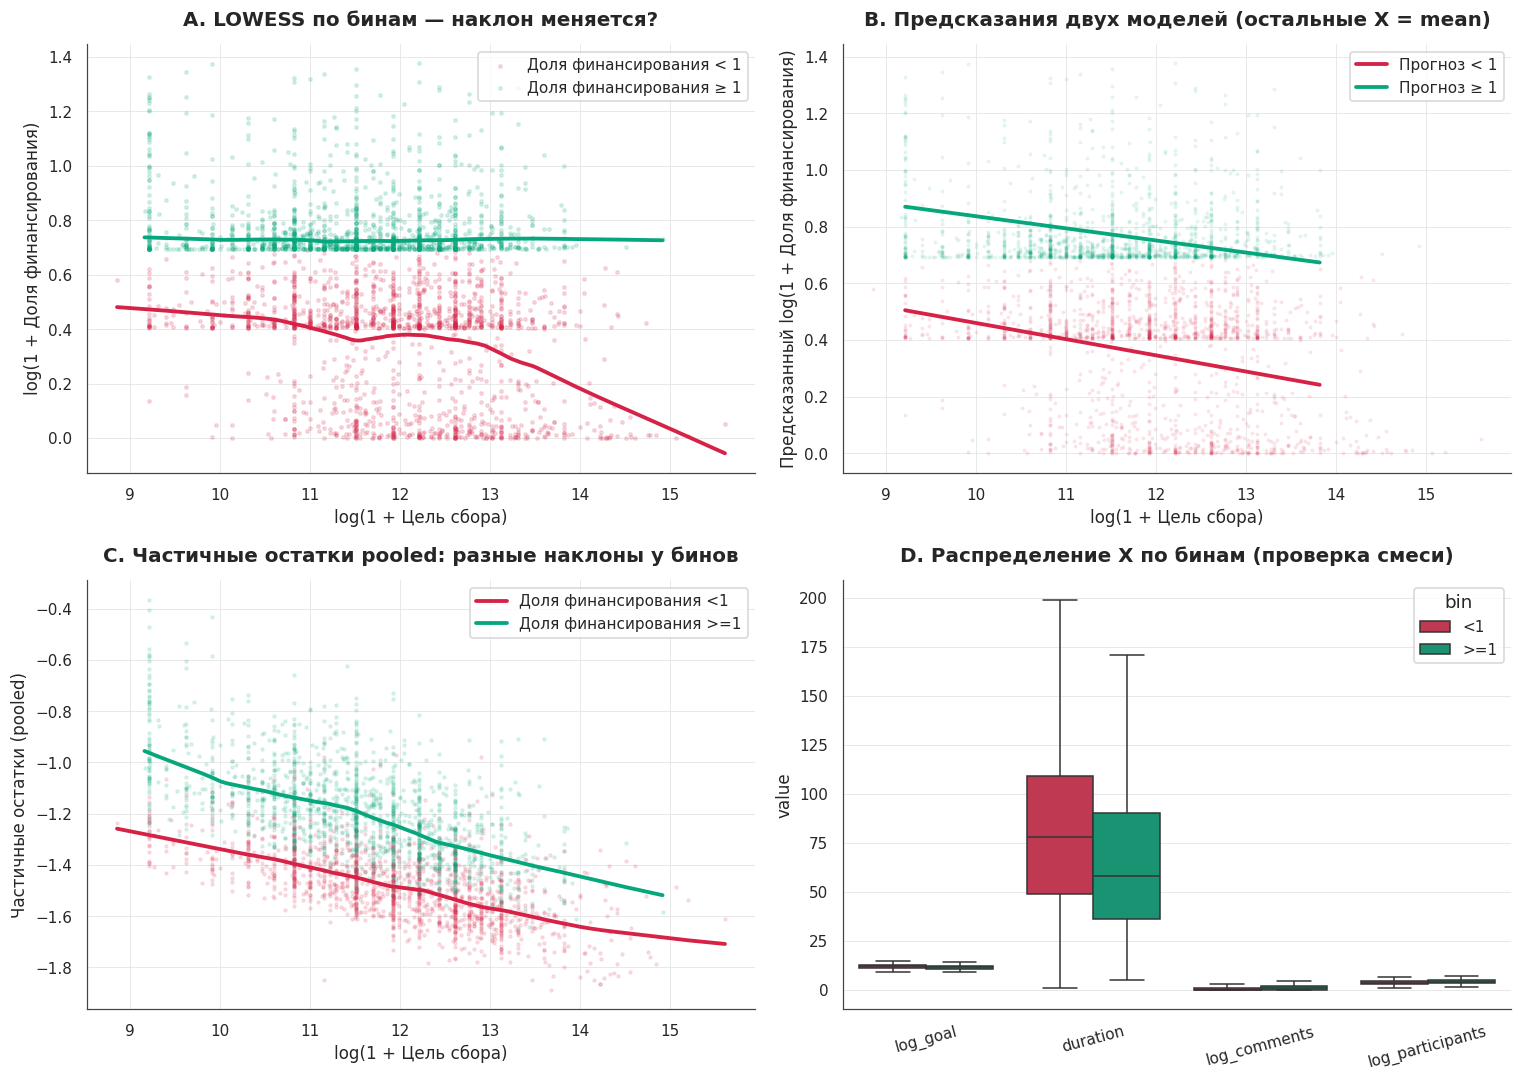

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- A. LOWESS по log_goal ---
ax = axes[0, 0]
for lbl, d, color in [('< 1', low, COLOR_FAIL), ('≥ 1', high, COLOR_SUCCESS)]:
    x = d['log_goal'].values
    y = d['log_funding'].values
    ax.scatter(x, y, s=5, alpha=0.15, color=color, label=f'Доля финансирования {lbl}')
    lo = lowess(y, x, frac=0.3, return_sorted=True)
    ax.plot(lo[:, 0], lo[:, 1], color=color, lw=2.5)
ax.set_xlabel('log(1 + Цель сбора)')
ax.set_ylabel('log(1 + Доля финансирования)')
ax.set_title('A. LOWESS по бинам — наклон меняется?')
ax.legend()

# --- B. Предсказания каждой сегментной модели (остальные X на средних) ---
ax = axes[0, 1]
xs = np.linspace(design['log_goal'].quantile(0.02),
                 design['log_goal'].quantile(0.98), 60)
for lbl, m, d, color in [('< 1', m_lo, low, COLOR_FAIL),
                          ('≥ 1', m_hi, high, COLOR_SUCCESS)]:
    means = d[regressors].mean()
    X_new = pd.DataFrame({c: [means[c]] * len(xs) for c in regressors})
    X_new['log_goal'] = xs
    X_new = sm.add_constant(X_new[regressors].astype(float), has_constant='add')
    pred = m.predict(X_new)
    ax.plot(xs, pred, color=color, lw=2.5, label=f'Прогноз {lbl}')
    ax.scatter(d['log_goal'], d['log_funding'], s=3, alpha=0.08, color=color)
ax.set_xlabel('log(1 + Цель сбора)')
ax.set_ylabel('Предсказанный log(1 + Доля финансирования)')
ax.set_title('B. Предсказания двух моделей (остальные X = mean)')
ax.legend()

# --- C. Частичные остатки по log_goal (pooled) ---
ax = axes[1, 0]
part = pooled.resid.values + pooled.params['log_goal'] * design['log_goal'].values
part_df = pd.DataFrame({
    'log_goal': design['log_goal'].values,
    'partial': part,
    'bin': np.where(design['funding_ratio'] < 1, '<1', '>=1'),
})
for lbl, color in [('<1', COLOR_FAIL), ('>=1', COLOR_SUCCESS)]:
    sub = part_df[part_df['bin'] == lbl]
    ax.scatter(sub['log_goal'], sub['partial'], s=4, alpha=0.12, color=color)
    lo = lowess(sub['partial'].values, sub['log_goal'].values,
                frac=0.3, return_sorted=True)
    ax.plot(lo[:, 0], lo[:, 1], color=color, lw=2.5, label=f'Доля финансирования {lbl}')
ax.set_xlabel('log(1 + Цель сбора)')
ax.set_ylabel('Частичные остатки (pooled)')
ax.set_title('C. Частичные остатки pooled: разные наклоны у бинов')
ax.legend()

# --- D. Boxplots ключевых предикторов по бинам (контроль смеси) ---
ax = axes[1, 1]
box_rows = []
for name, col in [('log_goal', 'log_goal'), ('duration', 'duration'),
                  ('log_comments', 'log_comments'), ('log_participants', 'log_participants')]:
    for label, d in [('<1', low), ('>=1', high)]:
        for v in d[col].values:
            box_rows.append({'variable': name, 'bin': label, 'value': v})
box_df = pd.DataFrame(box_rows)
sns.boxplot(data=box_df, x='variable', y='value', hue='bin', ax=ax,
            palette={'<1': COLOR_FAIL, '>=1': COLOR_SUCCESS}, showfliers=False)
ax.set_title('D. Распределение X по бинам (проверка смеси)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### 12.H. Выводы

Что даёт связка **спецификация + размеры + RSS + F + коэффициенты + графики**:

1. **Формальный ответ (E).** Чоу-тест либо отвергает $H_0$ на α=0.05, либо нет — это однозначное утверждение о том, что модели различаются структурно.
2. **Содержательный ответ (F).** Таблица коэффициентов показывает, **что именно** различается: у `log_goal` эластичность может менять знак (у недобравших больше цель → меньше доля сборов, у собравших — почти единичная эластичность), у `log_comments` и `log_participants` разная чувствительность к вовлечённости, у FE-годов — разные временные эффекты.
3. **Визуальный ответ (G).** LOWESS и partial residual plot показывают, что наклоны действительно разные: это не артефакт линейной формы — даже гибкая непараметрическая кривая ведёт себя по-разному в двух режимах.
4. **Качество разбиения (C, D-бокс).** Группы сопоставимы по размеру, обе проходят порог на $\sim 10\cdot k$ наблюдений; boxplot'ы показывают, насколько похожи распределения $X$ в двух группах (если сильно разные — вывод о «разном режиме» частично объясняется разными ковариатами).

**Практический вывод для основной части диплома:** если H0 отвергнут, единую регрессию `funding_ratio ~ X` нельзя использовать. Нужны либо:
- две отдельные модели (piecewise);
- взаимодействия `1[funding_ratio ≥ 1] × X` в одной модели;
- threshold-regression (Hansen) для определения порога эндогенно.

## 13. Тест Чоу: три режима финансирования

Проверяем, одинаковы ли коэффициенты регрессии в **трёх** сегментах:
- **[0, 0.5)** — сильный недобор;
- **[0.5, 1)** — почти-успех;
- **≥ 1** — цель достигнута.

Обобщённая статистика Чоу для G групп:

$$F = \frac{(RSS_p - \sum_{g=1}^{G} RSS_g) / ((G-1)\cdot k)}{\sum_{g=1}^{G} RSS_g / (n - G\cdot k)} \sim F\bigl((G-1)k,\ n - Gk\bigr)$$

**H₀:** коэффициенты регрессии одинаковы во всех трёх бинах.  
**H₁:** хотя бы один бин имеет структурно иные коэффициенты.

In [30]:
# Тест Чоу: 3 бина по funding_ratio
# Используем design, regressors, fit_ols, k_params из секции 12

bins_3 = pd.cut(design['funding_ratio'],
                bins=[-np.inf, 0.5, 1.0, np.inf],
                labels=['[0, 0.5)', '[0.5, 1)', '>=1'])

g1 = design[bins_3 == '[0, 0.5)']
g2 = design[bins_3 == '[0.5, 1)']
g3 = design[bins_3 == '>=1']

m1 = fit_ols(g1)
m2 = fit_ols(g2)
m3 = fit_ols(g3)

G       = 3
k       = k_params
n       = len(design)
rss_p   = fit_ols(design).ssr
rss_sum = m1.ssr + m2.ssr + m3.ssr
df1_3   = (G - 1) * k
df2_3   = n - G * k
F3      = ((rss_p - rss_sum) / df1_3) / (rss_sum / df2_3)
p3      = 1 - stats.f.cdf(F3, df1_3, df2_3)
crit3   = stats.f.ppf(0.95, df1_3, df2_3)

sizes_3 = pd.DataFrame({
    'группа': ['[0, 0.5) — сильный недобор', '[0.5, 1) — почти-успех', '>=1 — цель достигнута'],
    'n':      [len(g1), len(g2), len(g3)],
    'доля':   [f'{len(g1)/n*100:.1f}%', f'{len(g2)/n*100:.1f}%', f'{len(g3)/n*100:.1f}%'],
})
print(sizes_3.to_string(index=False))
print()

result_3 = pd.DataFrame({
    'метрика': ['G', 'k', 'df1 = (G-1)·k', 'df2 = n−G·k',
               'RSS pooled', 'RSS сумма сегментов', 'ΔRSS',
               'F-статистика', 'крит. F (α=0.05)', 'p-value',
               'решение H0', 'вывод'],
    'значение': [G, k, df1_3, df2_3,
                f'{rss_p:.4f}', f'{rss_sum:.4f}', f'{rss_p - rss_sum:.4f}',
                f'{F3:.4f}', f'{crit3:.4f}', f'{p3:.4g}',
                'ОТВЕРГАЕМ' if p3 < 0.05 else 'не отвергаем',
                'структурный сдвиг есть' if p3 < 0.05 else 'не обнаружен'],
})
print(result_3.to_string(index=False))
print()
print('H0: β([0,0.5)) = β([0.5,1)) = β(>=1) — одна модель адекватна во всех трёх режимах.')
print('H1: хотя бы одна группа структурно отличается.')

                    группа    n  доля
[0, 0.5) — сильный недобор  566 17.7%
    [0.5, 1) — почти-успех 1174 36.8%
     >=1 — цель достигнута 1452 45.5%

            метрика               значение
                  G                      3
                  k                     16
      df1 = (G-1)·k                     32
        df2 = n−G·k                   3144
         RSS pooled                97.9503
RSS сумма сегментов                30.8515
               ΔRSS                67.0987
       F-статистика               213.6831
   крит. F (α=0.05)                 1.4473
            p-value               1.11e-16
         решение H0              ОТВЕРГАЕМ
              вывод структурный сдвиг есть

H0: β([0,0.5)) = β([0.5,1)) = β(>=1) — одна модель адекватна во всех трёх режимах.
H1: хотя бы одна группа структурно отличается.


## 13. Описание корпуса

Для признаков с тяжёлыми правыми хвостами (skew > 2 по данным раздела 5) используется **медиана** вместо среднего — она устойчивее к выбросам и лучше отражает «типичный» проект.

In [31]:
import re

print("Описательная статистика успешных и неуспешных краудфандинговых проектов")

corpus = df.dropna(subset=['is_successful']).copy()

def count_sentences(text):
    if pd.isna(text):
        return 0
    return sum(1 for s in re.split(r'[.!?]+', str(text)) if s.strip())

corpus['n_sentences'] = corpus['description.text'].apply(count_sentences)

total = len(corpus)

# mean-aggregates (низкая/умеренная асимметрия или изначально заданные как средние)
mean_agg = corpus.groupby('is_successful').agg(
    n=('is_successful', 'size'),
    duration=('campaign_duration_days', 'mean'),
    goal=('card.targetAmount.value', 'mean'),
    sentences=('n_sentences', 'mean'),
    rewards=('rewards.totalRewards', 'mean'),
)

# median-aggregates (тяжёлые хвосты, skew > 2)
MEDIAN_COLS = {
    'desc_len':      'description_len_chars',
    'title_len':     'title_len_chars',
    'images':        'image_count',
    'videos':        'video_count',
    'funding_ratio': 'funding_ratio',
    'purchases':     'counts.purchasesCount',
    'participants':  'counts.participantsCount',
    'comments':      'counts.commentsCount',
    'news':          'counts.newsCount',
    'author_camps':  'card.author.campaignsAmount',
}
median_agg = corpus.groupby('is_successful')[list(MEDIAN_COLS.values())].median()
median_agg.columns = list(MEDIAN_COLS.keys())

# mode category
def mode_cat(sub):
    m = sub['category_grouped'].mode().iloc[0]
    n = (sub['category_grouped'] == m).sum()
    return f'{m} ({n})'

cat_mode = corpus.groupby('is_successful').apply(mode_cat)

def fmt_int(x):      return f'{int(round(x)):,}'.replace(',', ' ')
def fmt_one(x):      return f'{x:.1f}'
def fmt_two(x):      return f'{x:.2f}'

succ_m, fail_m = mean_agg.loc[1.0], mean_agg.loc[0.0]
succ_md, fail_md = median_agg.loc[1.0], median_agg.loc[0.0]

summary = pd.DataFrame({
    'Metric': [
        '# Campaigns', '% campaigns',
        'Duration in days (avg)', 'Goal amount (avg, ₽)',
        '# Sentences (avg)', '# Rewards offered (avg)',
        'Description length (median, chars)', 'Title length (median, chars)',
        '# Images (median)', '# Videos (median)',
        'Funding ratio (median)', '# Purchases (median)',
        '# Participants (median)', '# Comments (median)',
        '# News posts (median)', "# Author's past campaigns (median)",
        'Top category (mode)',
    ],
    'Successful': [
        int(succ_m['n']), f'{succ_m["n"] / total * 100:.1f}%',
        fmt_one(succ_m['duration']), fmt_int(succ_m['goal']),
        fmt_one(succ_m['sentences']), fmt_two(succ_m['rewards']),
        fmt_int(succ_md['desc_len']), fmt_int(succ_md['title_len']),
        fmt_int(succ_md['images']), fmt_int(succ_md['videos']),
        
        fmt_two(succ_md['funding_ratio']), fmt_int(succ_md['purchases']),
        fmt_one(succ_md['participants']), fmt_int(succ_md['comments']),
        fmt_int(succ_md['news']), fmt_int(succ_md['author_camps']),
        cat_mode.loc[1.0],
    ],
    'Failed': [
        int(fail_m['n']), f'{fail_m["n"] / total * 100:.1f}%',
        fmt_one(fail_m['duration']), fmt_int(fail_m['goal']),
        fmt_one(fail_m['sentences']), fmt_two(fail_m['rewards']),
        fmt_int(fail_md['desc_len']), fmt_int(fail_md['title_len']),
        fmt_int(fail_md['images']), fmt_int(fail_md['videos']),
        fmt_two(fail_md['funding_ratio']), fmt_int(fail_md['purchases']),
        fmt_one(fail_md['participants']), fmt_int(fail_md['comments']),
        fmt_int(fail_md['news']), fmt_int(fail_md['author_camps']),
        cat_mode.loc[0.0],
    ],
})
print(summary.to_string(index=False))

Описательная статистика успешных и неуспешных краудфандинговых проектов
                            Metric   Successful                    Failed
                       # Campaigns         1570                      1622
                       % campaigns        49.2%                     50.8%
            Duration in days (avg)         67.5                      88.4
              Goal amount (avg, ₽)      164 216                   274 868
                 # Sentences (avg)         36.5                      36.0
           # Rewards offered (avg)        10.35                      8.70
Description length (median, chars)        2 790                     2 959
      Title length (median, chars)           39                        38
                 # Images (median)           27                        26
                 # Videos (median)            1                         1
            Funding ratio (median)         1.06                      0.52
              # Purchases (median)      

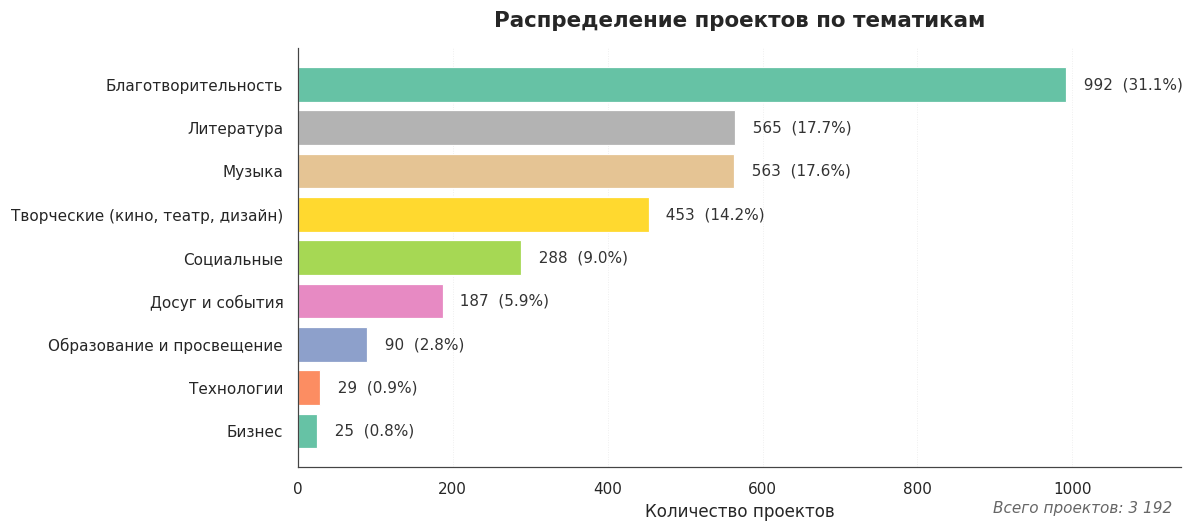

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Распределение проектов по тематикам
category_counts = (
    df["category_grouped"]
    .fillna("Не указано")
    .value_counts()
)

total = category_counts.sum()
category_share = (category_counts / total * 100).round(1)

# Горизонтальный bar — длинные названия читаются лучше
fig, ax = plt.subplots(figsize=(11, max(5, len(category_counts) * 0.45)))
order = category_counts.sort_values(ascending=True)

palette = sns.color_palette("Set2", n_colors=len(order))
bars = ax.barh(
    order.index, order.values,
    color=palette, edgecolor="white", linewidth=0.8,
)

ax.set_title("Распределение проектов по тематикам", fontsize=14, pad=14)
ax.set_xlabel("Количество проектов", fontsize=11)
ax.set_ylabel("")
ax.set_xlim(0, order.values.max() * 1.15)

# Числа и доли на барах
for bar, n in zip(bars, order.values):
    pct = n / total * 100
    ax.text(
        bar.get_width() + order.values.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"  {int(n):,}".replace(",", " ") + f"  ({pct:.1f}%)",
        va="center", fontsize=10, color="#333333",
    )

# Скрываем правую и верхнюю рамки уже глобально, тут добавим лёгкую сетку
ax.grid(axis="x", linestyle=":", linewidth=0.6, alpha=0.7)
ax.grid(axis="y", visible=False)

# Подпись с общим количеством
ax.text(
    0.99, -0.08,
    f"Всего проектов: {total:,}".replace(",", " "),
    transform=ax.transAxes, ha="right", va="top",
    fontsize=10, color="#666666", style="italic",
)

plt.tight_layout()
plt.show()


In [33]:
df.columns

Index(['project_key', 'sourceUrl', 'card.title', 'card.subtitle', 'card.collectedAmount.value', 'card.targetAmount.value', 'card.daysToFinish', 'card.startAt',
       'card.finishAt', 'card.region', 'card.mainCategory.tagName', 'card.author.id', 'card.author.campaignsAmount', 'card.links.vk_url',
       'card.links.telegram_url', 'card.links.author_site_url', 'description.text', 'counts.newsCount', 'counts.commentsCount', 'counts.participantsCount',
       'counts.purchasesCount', 'meta.description', 'rewards.totalRewards', 'image_count', 'video_count', 'reward_count', 'external_link_count',
       'funding_ratio', 'is_successful', 'campaign_duration_days', 'title_len_chars', 'subtitle_len_chars', 'description_len_chars',
       'meta_description_len_chars', 'title_word_count', 'subtitle_word_count', 'description_word_count', 'meta_description_word_count',
       'description_has_link_word', 'category_grouped', 'start_year', 'start_month'],
      dtype='object')

In [34]:
import pandas as pd
import numpy as np

# ── 1. Определяем числовые переменные для таблицы ──────────────────────────
numeric_vars = {
    'card.targetAmount.value':        'Целевая сумма, руб.',
    'card.collectedAmount.value':     'Собранная сумма, руб.',
    'funding_ratio':                  'Отношение собранной суммы к целевой',
    'campaign_duration_days':         'Длительность кампании, дней',
    'counts.participantsCount':       'Количество участников',
    'counts.purchasesCount':          'Количество покупок / поддержек',
    'counts.commentsCount':           'Количество комментариев',
    'counts.newsCount':               'Количество новостей / обновлений',
    'card.author.campaignsAmount':    'Количество прошлых кампаний автора',
    'reward_count':                   'Количество уровней вознаграждений',
    'image_count':                    'Количество изображений',
    'video_count':                    'Количество видео',
    'external_link_count':            'Количество внешних ссылок',
    'title_len_chars':                'Длина заголовка, знаков',
    'subtitle_len_chars':             'Длина подзаголовка, знаков',
    'description_len_chars':          'Длина описания, знаков',
    'description_word_count':         'Длина описания, слов',
}

# ── 2. Вспомогательная функция: статистики для одной группы ────────────────
def compute_stats(data: pd.DataFrame, col: str) -> dict:
    s = data[col].dropna()
    return {
        'N':      s.count(),
        'Mean':   s.mean(),
        'Median': s.median(),
        'Std':    s.std(),
        'Min':    s.min(),
        'Max':    s.max(),
    }

# ── 3. Разбиваем на группы ─────────────────────────────────────────────────
df_success = df[df['is_successful'] == 1]
df_fail    = df[df['is_successful'] == 0]

groups = {
    'Успешные':    df_success,
    'Неуспешные':  df_fail,
    'Вся выборка': df,
}

# ── 4. Строим мультииндексную таблицу ──────────────────────────────────────
stat_cols  = ['N', 'Mean', 'Median', 'Std', 'Min', 'Max']
group_keys = list(groups.keys())

index   = pd.MultiIndex.from_product([group_keys, stat_cols],
                                     names=['Группа', 'Статистика'])
table   = pd.DataFrame(index=index,
                       columns=list(numeric_vars.values()),
                       dtype=float)

for group_name, group_df in groups.items():
    for col, label in numeric_vars.items():
        if col not in group_df.columns:
            continue
        stats = compute_stats(group_df, col)
        for stat_name, value in stats.items():
            table.loc[(group_name, stat_name), label] = value

# ── 5. Транспонируем: переменные — строки, группы×статистики — столбцы ──────
table_T = table.T

# ── 6. Округление ──────────────────────────────────────────────────────────
int_cols_labels = {
    'Целевая сумма, руб.',
    'Собранная сумма, руб.',
    'Длина описания, знаков',
    'Длина описания, слов',
    'Длина заголовка, знаков',
    'Длина подзаголовка, знаков',
}

for label in table_T.index:
    decimals = 0 if label in int_cols_labels else 2
    table_T.loc[label] = table_T.loc[label].apply(
        lambda x: round(x, decimals) if pd.notna(x) else x
    )

# ── 7. Вывод ───────────────────────────────────────────────────────────────
pd.set_option('display.max_columns',  None)
pd.set_option('display.max_rows',     None)
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.width',        200)

print("=" * 120)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ ВЫБОРКИ")
print("=" * 120)
print(table_T.to_string())

ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ ВЫБОРКИ
Группа                              Успешные                                                         Неуспешные                                                        Вся выборка                                                       
Статистика                                 N       Mean     Median        Std       Min          Max          N       Mean     Median        Std      Min          Max           N       Mean     Median        Std      Min          Max
Целевая сумма, руб.                 1,570.00 164,216.00 100,000.00 189,923.00  9,500.00 3,000,000.00   1,622.00 274,868.00 155,863.00 370,903.00 7,000.00 6,000,000.00    3,192.00 220,443.00 130,000.00 301,133.00 7,000.00 6,000,000.00
Собранная сумма, руб.               1,570.00 193,033.00 117,938.00 229,229.00 10,000.00 3,235,000.00   1,622.00  97,986.00  51,085.00 135,422.00     0.00 1,513,716.00    3,192.00 144,735.00  81,782.00 193,420.00     0.00 3,235,000.00
Отношение собранной суммы к целе

## 14. Опыт автора

`card.author.campaignsAmount` — сколько кампаний уже провёл автор на момент запуска текущей.
Проверяем: связан ли опыт с успешностью (эффект обучения vs. «выжженная» аудитория).

Описательная статистика: Кампаний у автора
count   3,192.00
mean        4.60
std         8.00
min         1.00
25%         1.00
50%         2.00
75%         5.00
90%        11.00
95%        16.00
99%        31.00
max        77.00
Name: card.author.campaignsAmount, dtype: float64
Медиана: 2
Проектов с 1 кампанией (новички): 1348 (42.2%)

Успешность по опыту автора:
           exp_bucket    n  success_rate  median_ratio
1 кампания\n(новичок) 1348          0.45          0.76
         2–3 кампании  848          0.50          1.00
        4–10 кампаний  641          0.53          1.00
         11+ кампаний  355          0.56          1.00


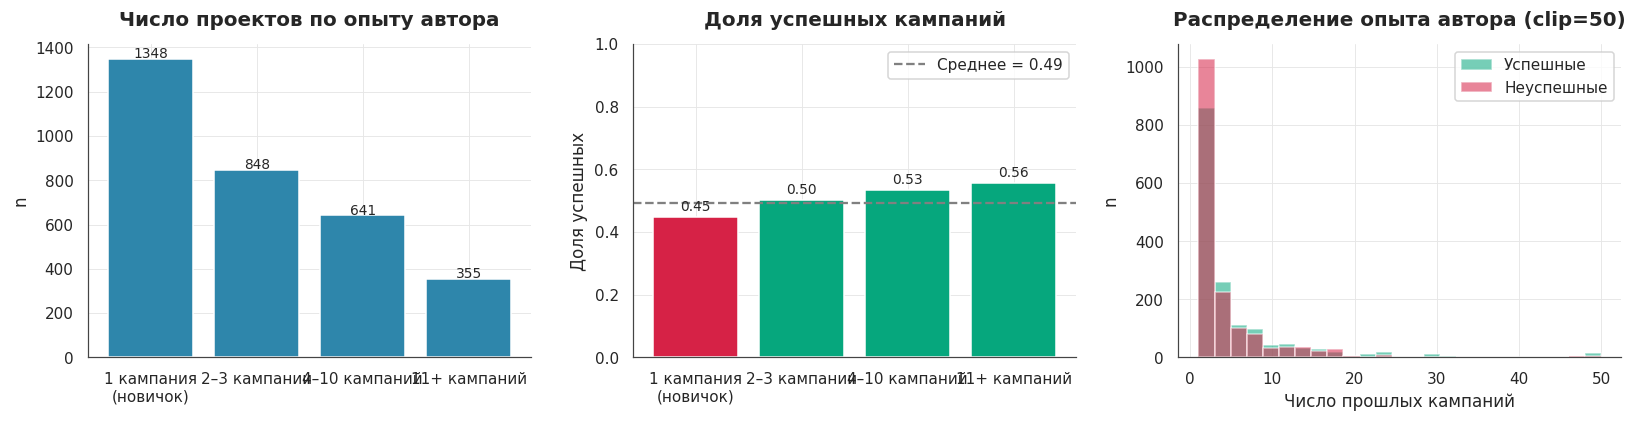

In [35]:
label = lambda c: COL_LABELS.get(c, c)  # восстанавливаем после затирания в ячейках 44/52
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as _stats

author_col = 'card.author.campaignsAmount'
df_a = df[df[author_col].notna()].copy()

# Распределение
print(f"Описательная статистика: {label(author_col)}")
print(df_a[author_col].describe(percentiles=[.25,.5,.75,.9,.95,.99]).round(1))
print(f"Медиана: {df_a[author_col].median():.0f}")
print(f"Проектов с 1 кампанией (новички): {(df_a[author_col] == 1).sum()} "
      f"({(df_a[author_col] == 1).mean()*100:.1f}%)")

# Бины опыта
bins   = [0, 1, 3, 10, df_a[author_col].max() + 1]
labels_b = ['1 кампания\n(новичок)', '2–3 кампании', '4–10 кампаний', '11+ кампаний']
df_a['exp_bucket'] = pd.cut(df_a[author_col], bins=bins, labels=labels_b, right=True)

bucket_stats = df_a.groupby('exp_bucket', observed=True).agg(
    n=('is_successful', 'count'),
    success_rate=('is_successful', 'mean'),
    median_ratio=('funding_ratio', 'median'),
).reset_index()
print("\nУспешность по опыту автора:")
print(bucket_stats.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) Число проектов по бинам
axes[0].bar(bucket_stats['exp_bucket'].astype(str), bucket_stats['n'],
            color=COLOR_PRIMARY, edgecolor='white')
axes[0].set_title('Число проектов по опыту автора')
axes[0].set_ylabel('n')
for i, row in bucket_stats.iterrows():
    axes[0].text(i, row['n'] + 5, str(int(row['n'])), ha='center', fontsize=9)

# (b) Доля успешных
colors_b = [COLOR_SUCCESS if v >= df_a['is_successful'].mean() else COLOR_FAIL
            for v in bucket_stats['success_rate']]
axes[1].bar(bucket_stats['exp_bucket'].astype(str), bucket_stats['success_rate'],
            color=colors_b, edgecolor='white')
axes[1].axhline(df_a['is_successful'].mean(), color='gray', ls='--',
                label=f'Среднее = {df_a["is_successful"].mean():.2f}')
axes[1].set_title('Доля успешных кампаний')
axes[1].set_ylabel('Доля успешных')
axes[1].set_ylim(0, 1)
axes[1].legend()
for i, row in bucket_stats.iterrows():
    axes[1].text(i, row['success_rate'] + 0.02, f"{row['success_rate']:.2f}",
                 ha='center', fontsize=9)

# (c) Логарифм числа кампаний (распределение)
for cls, color, lbl in [(1, COLOR_SUCCESS, 'Успешные'), (0, COLOR_FAIL, 'Неуспешные')]:
    sub = df_a[df_a['is_successful'] == cls][author_col].clip(upper=50)
    axes[2].hist(sub, bins=25, alpha=0.55, color=color, label=lbl, edgecolor='white')
axes[2].set_title('Распределение опыта автора (clip=50)')
axes[2].set_xlabel('Число прошлых кампаний')
axes[2].set_ylabel('n')
axes[2].legend()

plt.tight_layout()
plt.show()


## 15. Полнота профиля кампании

Проверяем, влияет ли наличие дополнительных элементов профиля (подзаголовок, видео,
ссылки на соцсети, мета-описание) на успешность кампании.

Влияние наличия элемента профиля на успешность:
         Элемент  Присутствует, n  Доля проектов, %  Успешность (есть)  Успешность (нет)  Δ success rate  chi2  p-value
 Ссылка Telegram              658             20.60               0.52              0.48            0.04  2.72     0.10
           Видео             1875             58.70               0.51              0.47            0.03  3.30     0.07
Ссылка ВКонтакте             2474             77.50               0.48              0.52           -0.04  3.59     0.06
     Сайт автора             1980             62.00               0.47              0.53           -0.07 13.50     0.00
    Подзаголовок             3192            100.00               0.49               NaN             NaN  0.00     1.00
   Мета-описание             3192            100.00               0.49               NaN             NaN  0.00     1.00
  Внешние ссылки             3192            100.00               0.49               NaN             NaN  0.00  

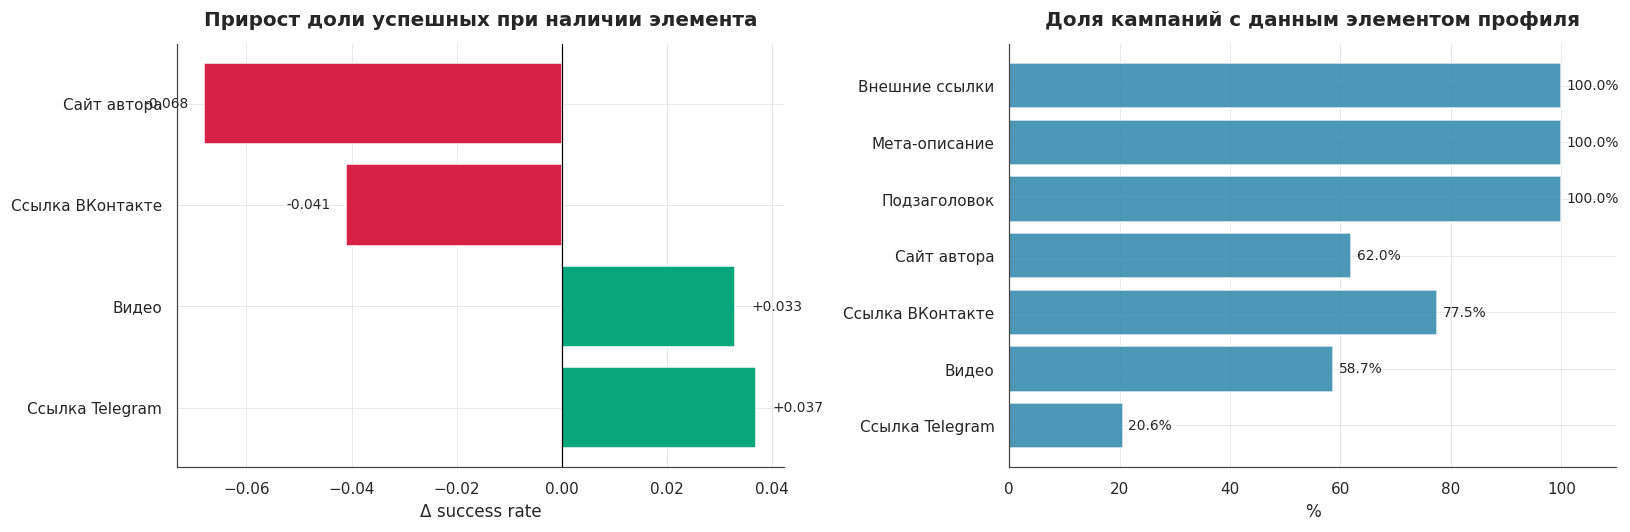

In [36]:
# Бинарные флаги наличия контента
df['has_subtitle']      = (df['subtitle_len_chars'].fillna(0) > 0).astype(int)
df['has_meta_desc']     = (df['meta_description_len_chars'].fillna(0) > 0).astype(int)
df['has_video']         = (df['video_count'].fillna(0) > 0).astype(int)
df['has_vk']            = df['card.links.vk_url'].notna().astype(int)
df['has_telegram']      = df['card.links.telegram_url'].notna().astype(int)
df['has_author_site']   = df['card.links.author_site_url'].notna().astype(int)
df['has_ext_links']     = (df['external_link_count'].fillna(0) > 0).astype(int)

content_flags = {
    'has_subtitle':    'Подзаголовок',
    'has_meta_desc':   'Мета-описание',
    'has_video':       'Видео',
    'has_vk':          'Ссылка ВКонтакте',
    'has_telegram':    'Ссылка Telegram',
    'has_author_site': 'Сайт автора',
    'has_ext_links':   'Внешние ссылки',
}

rows = []
for col, name in content_flags.items():
    n_present = df[col].sum()
    pct = n_present / len(df) * 100
    sr_yes = df[df[col] == 1]['is_successful'].mean()
    sr_no  = df[df[col] == 0]['is_successful'].mean()
    diff   = sr_yes - sr_no
    # Chi-square test
    ct = pd.crosstab(df[col], df['is_successful'])
    chi2, p, _, _ = _stats.chi2_contingency(ct)
    rows.append({'Элемент': name, 'Присутствует, n': int(n_present),
                 'Доля проектов, %': round(pct, 1),
                 'Успешность (есть)': round(sr_yes, 3),
                 'Успешность (нет)': round(sr_no, 3),
                 'Δ success rate': round(diff, 3),
                 'chi2': round(chi2, 2), 'p-value': round(p, 4)})

tbl = pd.DataFrame(rows).sort_values('Δ success rate', ascending=False)
print("Влияние наличия элемента профиля на успешность:")
print(tbl.to_string(index=False))

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

names  = tbl['Элемент'].tolist()
deltas = tbl['Δ success rate'].tolist()
colors_f = [COLOR_SUCCESS if d > 0 else COLOR_FAIL for d in deltas]

axes[0].barh(names, deltas, color=colors_f, edgecolor='white')
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('Прирост доли успешных при наличии элемента')
axes[0].set_xlabel('Δ success rate')
for i, (name, d) in enumerate(zip(names, deltas)):
    axes[0].text(d + (0.003 if d >= 0 else -0.003), i,
                 f'{d:+.3f}', va='center', ha='left' if d >= 0 else 'right', fontsize=9)

# Доля кампаний, имеющих элемент
pcts = tbl['Доля проектов, %'].tolist()
axes[1].barh(names, pcts, color=COLOR_PRIMARY, edgecolor='white', alpha=0.85)
axes[1].set_title('Доля кампаний с данным элементом профиля')
axes[1].set_xlabel('%')
axes[1].set_xlim(0, 110)
for i, p in enumerate(pcts):
    axes[1].text(p + 1, i, f'{p:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()


## 16. Сезонные паттерны запуска

Месяц старта кампании может влиять на успешность через доступность аудитории:
праздники, отпускной сезон, учебный год.

Сезонная статистика:
month_name   n  success_rate  median_target
       Янв 181          0.53     120,000.00
       Фев 277          0.53     126,000.00
       Мар 318          0.46     130,000.00
       Апр 301          0.44     150,000.00
       Май 258          0.50     120,000.00
       Июн 234          0.44     125,000.00
       Июл 249          0.49     138,215.00
       Авг 240          0.47     115,000.00
       Сен 251          0.49     150,000.00
       Окт 296          0.52     150,000.00
       Ноя 327          0.55     135,000.00
       Дек 260          0.50     129,000.00

По кварталам:
 start_quarter   n  success_rate
             1 776          0.50
             2 793          0.46
             3 740          0.49
             4 883          0.52


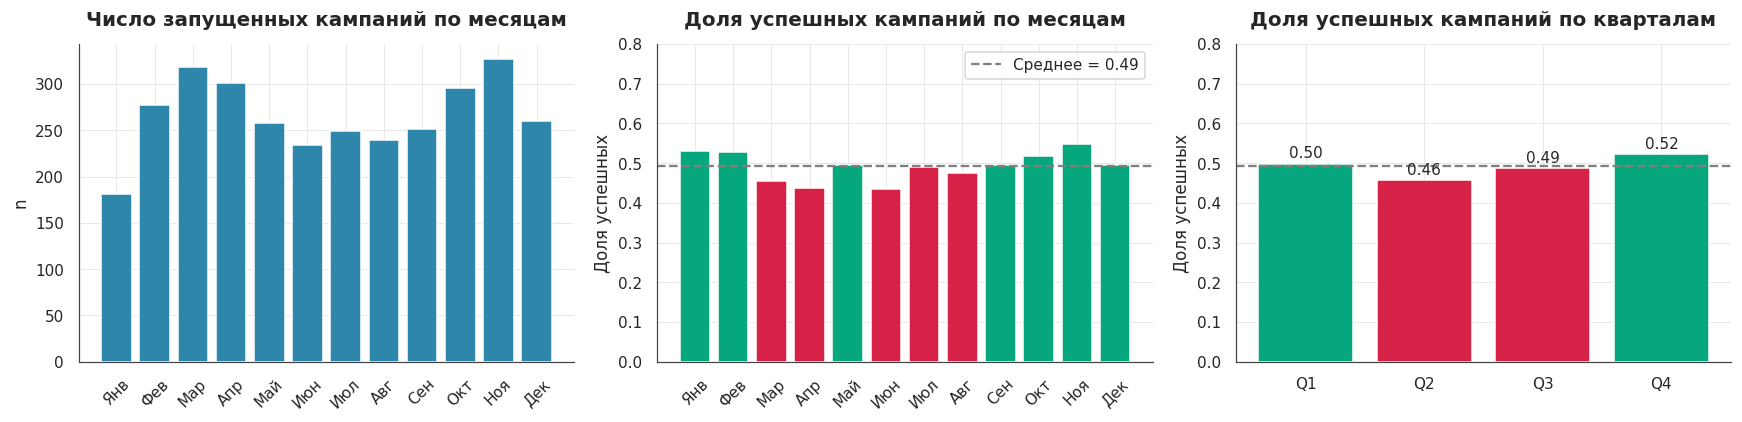

In [37]:
df['start_month_num'] = pd.to_datetime(df['card.startAt']).dt.month
df['start_quarter']   = pd.to_datetime(df['card.startAt']).dt.quarter

MONTH_NAMES = {1:'Янв', 2:'Фев', 3:'Мар', 4:'Апр', 5:'Май', 6:'Июн',
               7:'Июл', 8:'Авг', 9:'Сен', 10:'Окт', 11:'Ноя', 12:'Дек'}

by_month_stat = df.groupby('start_month_num').agg(
    n=('is_successful', 'count'),
    success_rate=('is_successful', 'mean'),
    median_target=('card.targetAmount.value', 'median'),
).reset_index()
by_month_stat['month_name'] = by_month_stat['start_month_num'].map(MONTH_NAMES)
print("Сезонная статистика:")
print(by_month_stat[['month_name','n','success_rate','median_target']].to_string(index=False))

by_q = df.groupby('start_quarter').agg(
    n=('is_successful', 'count'),
    success_rate=('is_successful', 'mean'),
).reset_index()
print("\nПо кварталам:")
print(by_q.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) Число запусков по месяцам
axes[0].bar(by_month_stat['month_name'], by_month_stat['n'],
            color=COLOR_PRIMARY, edgecolor='white')
axes[0].set_title('Число запущенных кампаний по месяцам')
axes[0].set_ylabel('n')
axes[0].tick_params(axis='x', rotation=45)

# (b) Доля успешных по месяцам
bar_colors = [COLOR_SUCCESS if v >= df['is_successful'].mean() else COLOR_FAIL
              for v in by_month_stat['success_rate']]
axes[1].bar(by_month_stat['month_name'], by_month_stat['success_rate'],
            color=bar_colors, edgecolor='white')
axes[1].axhline(df['is_successful'].mean(), color='gray', ls='--',
                label=f'Среднее = {df["is_successful"].mean():.2f}')
axes[1].set_title('Доля успешных кампаний по месяцам')
axes[1].set_ylabel('Доля успешных')
axes[1].set_ylim(0, 0.8)
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

# (c) Квартальная разбивка
q_colors = [COLOR_SUCCESS if v >= df['is_successful'].mean() else COLOR_FAIL
            for v in by_q['success_rate']]
axes[2].bar([f'Q{q}' for q in by_q['start_quarter']], by_q['success_rate'],
            color=q_colors, edgecolor='white')
axes[2].axhline(df['is_successful'].mean(), color='gray', ls='--')
axes[2].set_title('Доля успешных кампаний по кварталам')
axes[2].set_ylabel('Доля успешных')
axes[2].set_ylim(0, 0.8)
for i, row in by_q.iterrows():
    axes[2].text(i, row['success_rate'] + 0.015,
                 f"{row['success_rate']:.2f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()


## 17. Сравнение распределений по классу успеха (KDE)

KDE-графики для ключевых числовых признаков в разрезе `is_successful`.
Позволяют визуально оценить разделяющую способность каждой переменной.

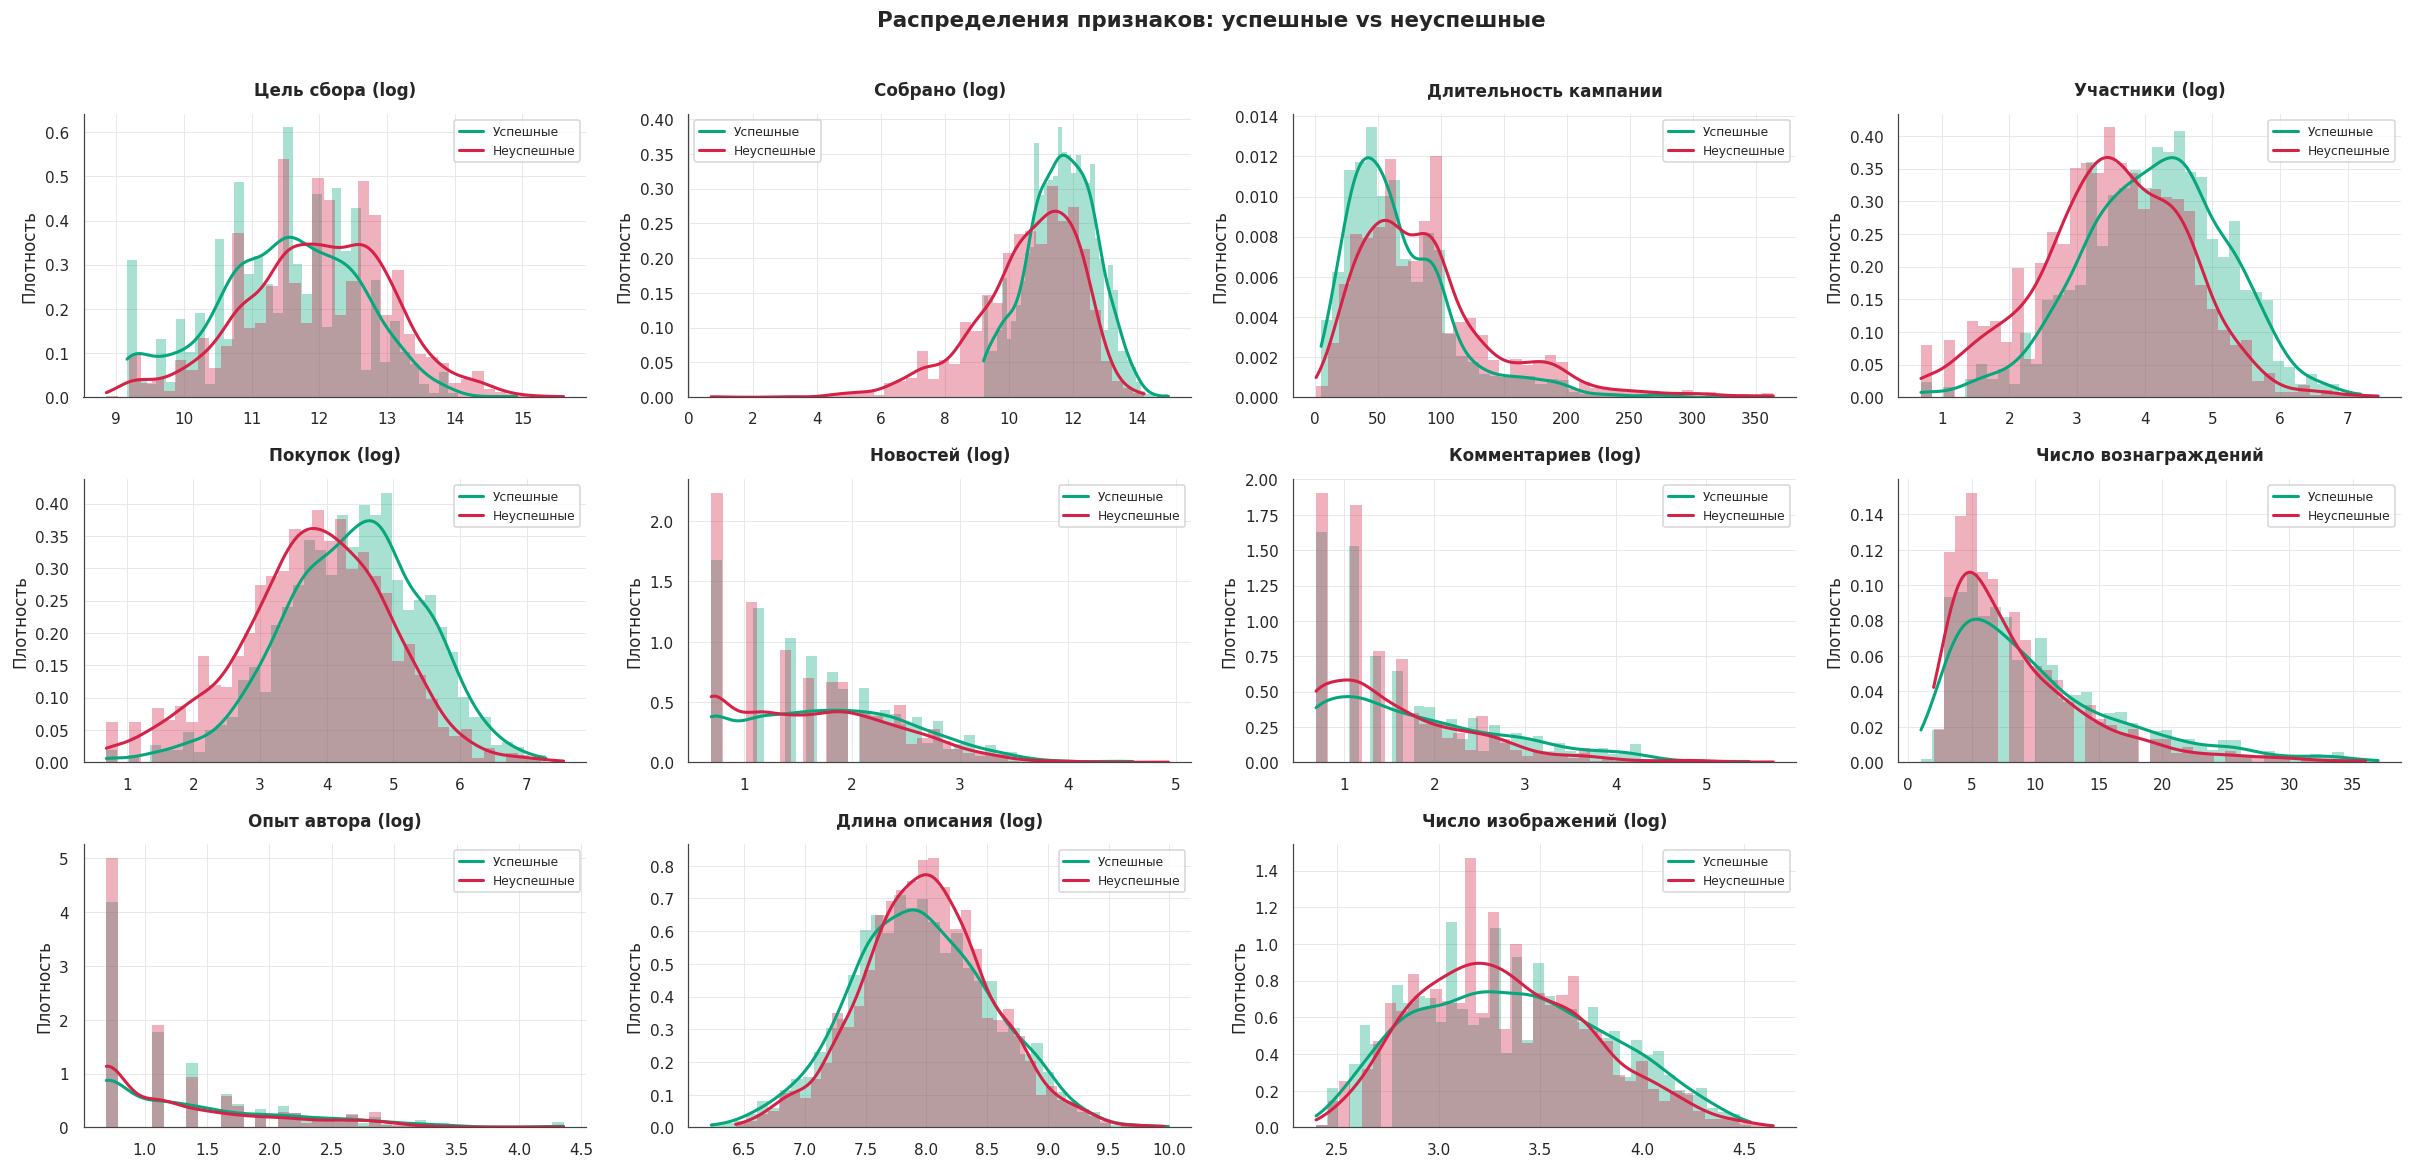

In [38]:
kde_vars = [
    ('card.targetAmount.value',    True,  'Цель сбора (log)'),
    ('card.collectedAmount.value', True,  'Собрано (log)'),
    ('campaign_duration_days',     False, 'Длительность кампании'),
    ('counts.participantsCount',   True,  'Участники (log)'),
    ('counts.purchasesCount',      True,  'Покупок (log)'),
    ('counts.newsCount',           True,  'Новостей (log)'),
    ('counts.commentsCount',       True,  'Комментариев (log)'),
    ('reward_count',               False, 'Число вознаграждений'),
    ('card.author.campaignsAmount',True,  'Опыт автора (log)'),
    ('description_len_chars',      True,  'Длина описания (log)'),
    ('image_count',                True,  'Число изображений (log)'),
]

ncol = 4
nrow = -(-len(kde_vars) // ncol)
fig, axes = plt.subplots(nrow, ncol, figsize=(5.5 * ncol, 3.5 * nrow))
axes = axes.ravel()

for ax, (col, use_log, title) in zip(axes, kde_vars):
    if col not in df.columns:
        ax.set_visible(False)
        continue
    for cls, color, lbl in [(1, COLOR_SUCCESS, 'Успешные'),
                             (0, COLOR_FAIL,    'Неуспешные')]:
        s = df[df['is_successful'] == cls][col].dropna()
        s = s[s > 0] if use_log else s
        if use_log and len(s) > 0:
            s = np.log1p(s)
        if len(s) < 5:
            continue
        ax.hist(s, bins=40, density=True, alpha=0.35, color=color, edgecolor='none')
        try:
            from scipy.stats import gaussian_kde
            kde = gaussian_kde(s, bw_method='scott')
            x_range = np.linspace(s.min(), s.max(), 300)
            ax.plot(x_range, kde(x_range), color=color, lw=2, label=lbl)
        except Exception:
            pass
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Плотность')
    ax.legend(fontsize=8)

for ax in axes[len(kde_vars):]:
    ax.set_visible(False)

plt.suptitle('Распределения признаков: успешные vs неуспешные', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 18. Статистические тесты различий (Mann-Whitney U)

Для каждого числового признака проверяем H₀: распределения в группах «успешные» и «неуспешные»
одинаковы. Используем тест Манна–Уитни (непараметрический, устойчив к выбросам).

**Размер эффекта** — ранговый бисериальный коэффициент корреляции:
$$r_{\text{rb}} = 1 - \frac{2U}{n_1 \cdot n_2}$$

Интерпретация |r_rb|: <0.1 — пренебрежимый, 0.1–0.3 — малый, 0.3–0.5 — средний, >0.5 — большой.

Тест Манна–Уитни: признаки, ранжированные по размеру эффекта
                    Признак  Медиана (успешные)  Медиана (неуспешные)  p-value  r_rb     Эффект sig
        Доля финансирования                1.06                  0.52     0.00 -1.00    большой ***
              Собрано, руб.          117,938.00             51,085.00     0.00 -0.38    средний ***
           Число участников               64.00                 34.00     0.00 -0.31    средний ***
              Число покупок               84.00                 45.00     0.00 -0.31    средний ***
           Цель сбора, руб.          100,000.00            155,863.00     0.00  0.24      малый ***
Длительность кампании, дней               58.00                 78.00     0.00  0.24      малый ***
             Число новостей                4.00                  2.00     0.00 -0.18      малый ***
         Число комментариев                1.00                  0.00     0.00 -0.16      малый ***
               Число наград            

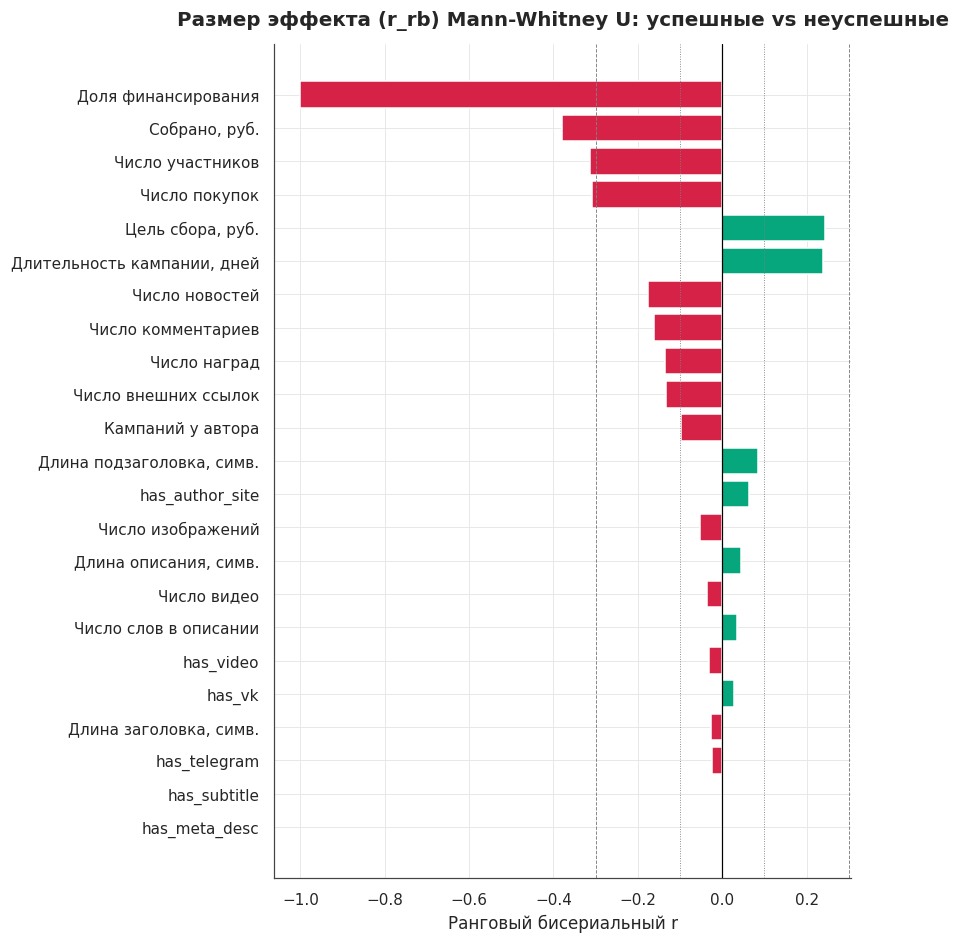

In [39]:
label = lambda c: COL_LABELS.get(c, c)  # восстанавливаем после затирания в ячейках 44/52
from scipy.stats import mannwhitneyu

test_vars = [
    'card.targetAmount.value', 'card.collectedAmount.value', 'funding_ratio',
    'campaign_duration_days',
    'counts.newsCount', 'counts.commentsCount',
    'counts.participantsCount', 'counts.purchasesCount',
    'image_count', 'video_count', 'reward_count', 'external_link_count',
    'card.author.campaignsAmount',
    'title_len_chars', 'subtitle_len_chars', 'description_len_chars',
    'description_word_count',
    'has_subtitle', 'has_meta_desc', 'has_video',
    'has_vk', 'has_telegram', 'has_author_site',
]
test_vars = [v for v in test_vars if v in df.columns]

success = df[df['is_successful'] == 1]
fail    = df[df['is_successful'] == 0]

rows = []
for col in test_vars:
    s1 = success[col].dropna().values
    s0 = fail[col].dropna().values
    if len(s1) < 2 or len(s0) < 2:
        continue
    U, p = mannwhitneyu(s1, s0, alternative='two-sided')
    n1, n0 = len(s1), len(s0)
    r_rb = 1 - 2 * U / (n1 * n0)
    rows.append({
        'Признак': label(col),
        'Медиана (успешные)': round(np.median(s1), 3),
        'Медиана (неуспешные)': round(np.median(s0), 3),
        'U': round(U, 0),
        'p-value': p,
        'r_rb': round(r_rb, 3),
        '|r_rb|': round(abs(r_rb), 3),
        'Эффект': ('большой' if abs(r_rb) > 0.5 else
                   'средний' if abs(r_rb) > 0.3 else
                   'малый'   if abs(r_rb) > 0.1 else 'незначимый'),
    })

mw_df = pd.DataFrame(rows).sort_values('|r_rb|', ascending=False)
mw_df['sig'] = mw_df['p-value'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else '—'))
)
pd.set_option('display.max_rows', 50)
print("Тест Манна–Уитни: признаки, ранжированные по размеру эффекта")
print(mw_df[['Признак','Медиана (успешные)','Медиана (неуспешные)',
             'p-value','r_rb','Эффект','sig']].to_string(index=False))

# График
fig, ax = plt.subplots(figsize=(8, max(5, 0.38 * len(mw_df))))
colors_m = [COLOR_SUCCESS if v > 0 else COLOR_FAIL for v in mw_df['r_rb']]
ax.barh(mw_df['Признак'][::-1], mw_df['r_rb'][::-1], color=colors_m[::-1], edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.axvline( 0.1, color='gray', lw=0.6, ls=':')
ax.axvline(-0.1, color='gray', lw=0.6, ls=':')
ax.axvline( 0.3, color='gray', lw=0.6, ls='--')
ax.axvline(-0.3, color='gray', lw=0.6, ls='--')
ax.set_title('Размер эффекта (r_rb) Mann-Whitney U: успешные vs неуспешные')
ax.set_xlabel('Ранговый бисериальный r')
plt.tight_layout()
plt.show()


## 19. Взаимная информация (Mutual Information)

Mutual Information — нелинейная мера зависимости между признаком и целевой переменной.
В отличие от корреляции Пирсона, улавливает любые монотонные и немонотонные связи.

Mutual Information с is_successful (топ признаки):
                    Признак   MI
           Число участников 0.04
              Число покупок 0.03
Длительность кампании, дней 0.03
             Число новостей 0.02
                     has_vk 0.02
               Число наград 0.02
           Цель сбора, руб. 0.02
                  has_video 0.01
         Число комментариев 0.01
               has_telegram 0.01
      Число слов в описании 0.01
      Длина описания, симв. 0.01
              has_meta_desc 0.00
                Число видео 0.00
          Кампаний у автора 0.00
               has_subtitle 0.00
     Длина заголовка, симв. 0.00
       Число внешних ссылок 0.00
          Число изображений 0.00
            has_author_site 0.00


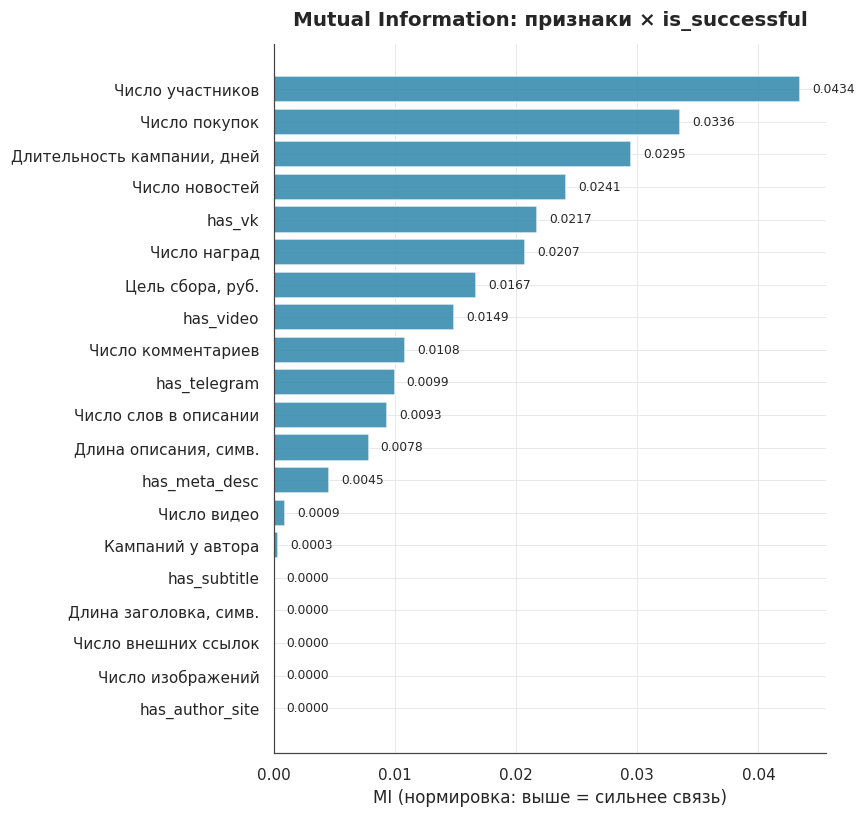

In [40]:
label = lambda c: COL_LABELS.get(c, c)  # восстанавливаем после затирания в ячейках 44/52
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import QuantileTransformer

mi_vars = [
    'card.targetAmount.value', 'campaign_duration_days',
    'counts.newsCount', 'counts.commentsCount',
    'counts.participantsCount', 'counts.purchasesCount',
    'image_count', 'video_count', 'reward_count', 'external_link_count',
    'card.author.campaignsAmount',
    'title_len_chars', 'description_len_chars', 'description_word_count',
    'has_subtitle', 'has_meta_desc', 'has_video',
    'has_vk', 'has_telegram', 'has_author_site',
]
mi_vars = [v for v in mi_vars if v in df.columns]

df_mi = df[mi_vars + ['is_successful']].dropna()
X_mi = df_mi[mi_vars].astype(float)
y_mi = df_mi['is_successful'].astype(int)

# log1p для сильно скошенных (улучшает оценку MI)
skew_cols = X_mi.apply(lambda s: abs(s.skew())).sort_values(ascending=False)
for col in skew_cols[skew_cols > 2].index:
    X_mi[col] = np.log1p(X_mi[col].clip(lower=0))

mi_scores = mutual_info_classif(X_mi, y_mi, discrete_features=False,
                                 n_neighbors=5, random_state=42)
mi_df = pd.DataFrame({'Признак': [label(v) for v in mi_vars],
                       'MI': mi_scores}).sort_values('MI', ascending=False)

print("Mutual Information с is_successful (топ признаки):")
print(mi_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, max(4, 0.38 * len(mi_df))))
ax.barh(mi_df['Признак'][::-1], mi_df['MI'][::-1],
        color=COLOR_PRIMARY, edgecolor='white', alpha=0.85)
ax.set_title('Mutual Information: признаки × is_successful')
ax.set_xlabel('MI (нормировка: выше = сильнее связь)')
for i, (_, row) in enumerate(mi_df[::-1].iterrows()):
    ax.text(row['MI'] + 0.001, i, f'{row["MI"]:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()


## 20. Региональный анализ

Проверяем, различается ли успешность кампаний по регионам России.

Проектов с указанным регионом: 2221 (69.6%)
Уникальных регионов: 99

Топ-15 регионов (≥10 проектов):
                                           n  success_rate  median_target
card.region                                                              
Москва и Московская обл.                 819          0.52     175,000.00
Санкт-Петербург и Ленинградская область  317          0.52     139,995.00
Свердловская обл.                         81          0.46     120,000.00
Нижегородская (Горьковская)               73          0.41      30,000.00
Краснодарский край                        41          0.41     150,000.00
Челябинская обл.                          36          0.42      89,500.00
Новосибирская обл.                        34          0.47      74,000.00
Башкортостан(Башкирия)                    32          0.50     137,000.00
Кемеровская обл.                          31          0.39      70,000.00
Удмуртия                                  31          0.39      80,000.00
Ростовская 

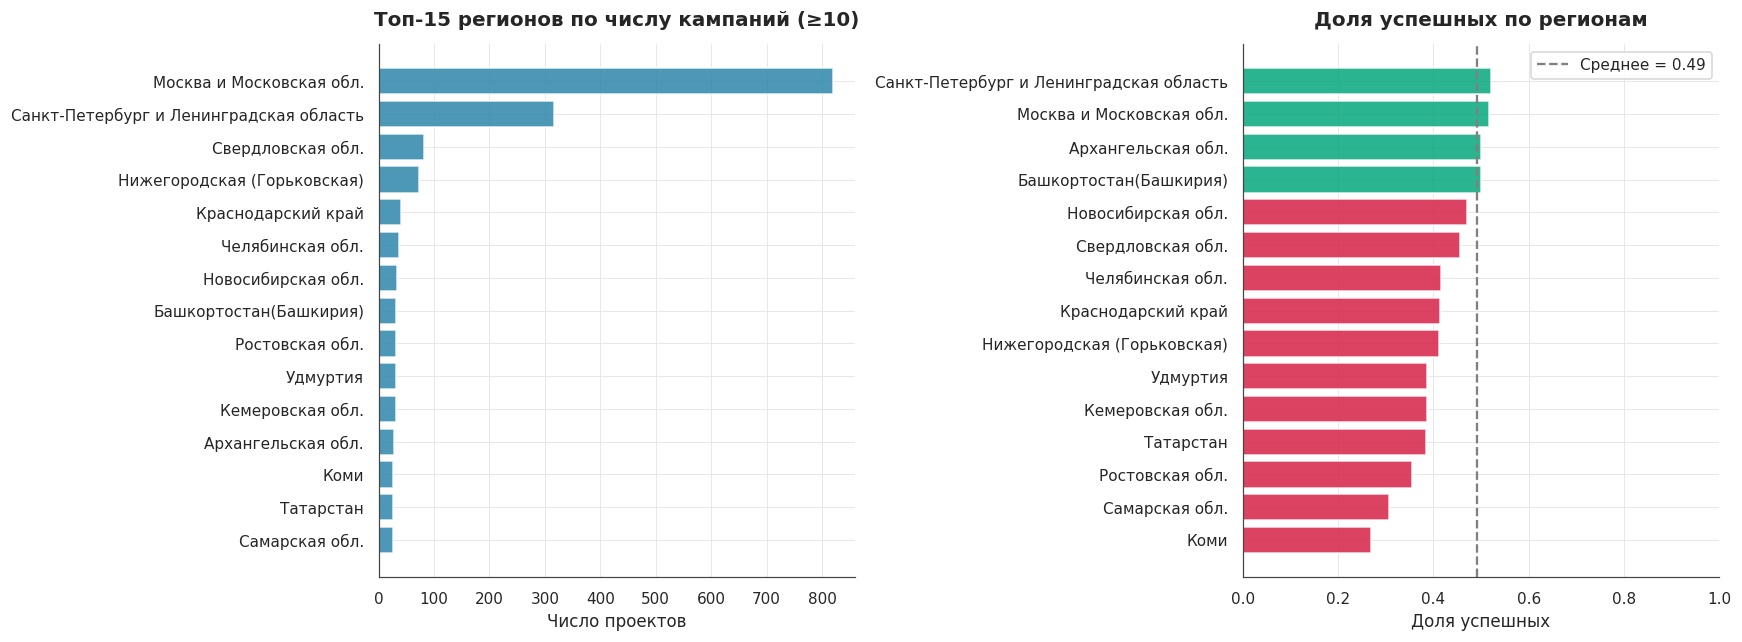

In [41]:
region_col = 'card.region'
df_reg = df[df[region_col].notna()].copy()
print(f"Проектов с указанным регионом: {len(df_reg)} ({len(df_reg)/len(df)*100:.1f}%)")
print(f"Уникальных регионов: {df_reg[region_col].nunique()}")

reg_stats = (
    df_reg.groupby(region_col)
    .agg(n=('is_successful', 'count'),
         success_rate=('is_successful', 'mean'),
         median_target=('card.targetAmount.value', 'median'))
    .query('n >= 10')
    .sort_values('n', ascending=False)
    .head(15)
)
print("\nТоп-15 регионов (≥10 проектов):")
print(reg_stats.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Топ-15 по числу проектов
top_n = reg_stats.sort_values('n', ascending=True)
axes[0].barh(top_n.index.astype(str), top_n['n'],
             color=COLOR_PRIMARY, edgecolor='white', alpha=0.85)
axes[0].set_title('Топ-15 регионов по числу кампаний (≥10)')
axes[0].set_xlabel('Число проектов')

# Success rate по регионам
sr = reg_stats.sort_values('success_rate', ascending=True)
colors_r = [COLOR_SUCCESS if v >= df['is_successful'].mean() else COLOR_FAIL
            for v in sr['success_rate']]
axes[1].barh(sr.index.astype(str), sr['success_rate'],
             color=colors_r, edgecolor='white', alpha=0.85)
axes[1].axvline(df['is_successful'].mean(), color='gray', ls='--',
                label=f'Среднее = {df["is_successful"].mean():.2f}')
axes[1].set_title('Доля успешных по регионам')
axes[1].set_xlabel('Доля успешных')
axes[1].set_xlim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()


## 21. Двумерный анализ: цель × длительность кампании

Scatter-plot в лог-шкале с раскраской по успешности.
Помогает выявить «зону успеха» и проверить, есть ли оптимум по обоим измерениям.

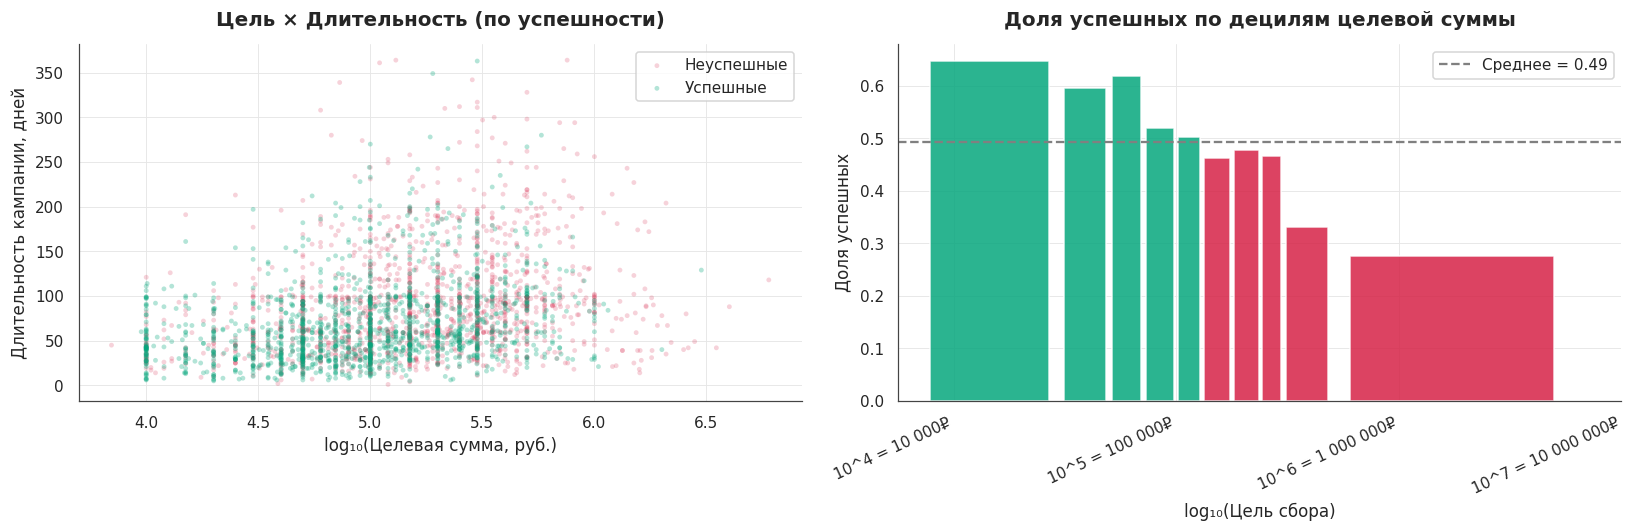

In [42]:
df_sc = df.dropna(subset=['card.targetAmount.value', 'campaign_duration_days',
                                          'is_successful']).copy()
df_sc = df_sc[df_sc['card.targetAmount.value'] > 0]
df_sc['log_goal_sc']  = np.log10(df_sc['card.targetAmount.value'])
df_sc['log_dur_sc']   = np.log10(df_sc['campaign_duration_days'].clip(lower=1))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (x_col, x_label) in zip(axes, [
    ('log_goal_sc', 'log₁₀(Цель сбора, руб.)'),
    ('log_dur_sc',  'log₁₀(Длительность, дней)'),
]):
    for cls, color, lbl, alpha in [(0, COLOR_FAIL, 'Неуспешные', 0.25),
                                    (1, COLOR_SUCCESS, 'Успешные', 0.35)]:
        sub = df_sc[df_sc['is_successful'] == cls]
        ax.scatter(sub[x_col],
                   np.log10(sub['card.targetAmount.value']) if x_col != 'log_goal_sc'
                   else sub['log_dur_sc'],
                   alpha=alpha, s=12, color=color, label=lbl, edgecolors='none')
    ax.set_xlabel(x_label)
    ax.set_ylabel('log₁₀(Длительность)' if x_col == 'log_goal_sc' else 'log₁₀(Цель)')
    ax.legend()

# Правильный scatter: goal × duration с цветом успешности
axes[0].cla()
axes[1].cla()

for cls, color, lbl, alpha in [(0, COLOR_FAIL, 'Неуспешные', 0.20),
                                (1, COLOR_SUCCESS, 'Успешные',   0.30)]:
    sub = df_sc[df_sc['is_successful'] == cls]
    axes[0].scatter(sub['log_goal_sc'], sub['campaign_duration_days'],
                    alpha=alpha, s=10, color=color, label=lbl, edgecolors='none')

axes[0].set_xlabel('log₁₀(Целевая сумма, руб.)')
axes[0].set_ylabel('Длительность кампании, дней')
axes[0].set_title('Цель × Длительность (по успешности)')
axes[0].legend()

# Binned success rate по log_goal
bins_g = np.percentile(df_sc['log_goal_sc'], np.linspace(0, 100, 11))
bins_g = np.unique(bins_g)
df_sc['goal_bin'] = pd.cut(df_sc['log_goal_sc'], bins=bins_g, include_lowest=True)
goal_sr = df_sc.groupby('goal_bin', observed=True).agg(
    n=('is_successful', 'count'),
    sr=('is_successful', 'mean')
).reset_index()
x_centers = [(float(str(b).strip('(]').split(',')[0]) +
               float(str(b).strip('(]').split(',')[1])) / 2
              for b in goal_sr['goal_bin']]
axes[1].bar(x_centers, goal_sr['sr'], width=np.diff(bins_g) * 0.85,
            color=[COLOR_SUCCESS if v >= df['is_successful'].mean() else COLOR_FAIL
                   for v in goal_sr['sr']], edgecolor='white', alpha=0.85,
            align='center')
axes[1].axhline(df['is_successful'].mean(), color='gray', ls='--',
                label=f'Среднее = {df["is_successful"].mean():.2f}')
axes[1].set_xlabel('log₁₀(Цель сбора)')
axes[1].set_ylabel('Доля успешных')
axes[1].set_title('Доля успешных по децилям целевой суммы')
axes[1].legend()
tick_vals = np.arange(4, 8)
axes[1].set_xticks(tick_vals)
axes[1].set_xticklabels([f'10^{int(v)} = {10**v:,.0f}₽'.replace(',', ' ')
                          for v in tick_vals], rotation=25, ha='right')

plt.tight_layout()
plt.show()


## 22. Связь категориальных признаков с успехом (χ²)

Chi-square тест для всех бинарных флагов и категориальной переменной.

In [43]:
from scipy.stats import chi2_contingency

cat_tests = {
    'Категория проекта':           'category_grouped',
    'Наличие подзаголовка':        'has_subtitle',
    'Наличие мета-описания':       'has_meta_desc',
    'Наличие видео':               'has_video',
    'Ссылка ВКонтакте':            'has_vk',
    'Ссылка Telegram':             'has_telegram',
    'Сайт автора':                 'has_author_site',
    'Внешние ссылки в описании':   'has_ext_links',
}

chi2_rows = []
for name, col in cat_tests.items():
    if col not in df.columns:
        continue
    ct = pd.crosstab(df[col], df['is_successful'])
    chi2, p, dof, _ = chi2_contingency(ct)
    # Cramér's V
    n   = ct.values.sum()
    k   = min(ct.shape) - 1
    V   = np.sqrt(chi2 / (n * max(k, 1)))
    chi2_rows.append({'Признак': name, 'χ²': round(chi2, 2), 'df': dof,
                       'p-value': p, "Cramér's V": round(V, 3),
                       'sig': ('***' if p < 0.001 else '**' if p < 0.01
                               else '*' if p < 0.05 else '—')})

chi2_df = pd.DataFrame(chi2_rows).sort_values("Cramér's V", ascending=False)
print("Chi-square тесты (ранжированы по силе связи Cramér's V):")
print(chi2_df.to_string(index=False))


Chi-square тесты (ранжированы по силе связи Cramér's V):
                  Признак     χ²  df  p-value  Cramér's V sig
        Категория проекта 183.10   8     0.00        0.24 ***
              Сайт автора  13.50   1     0.00        0.07 ***
         Ссылка ВКонтакте   3.59   1     0.06        0.03   —
            Наличие видео   3.30   1     0.07        0.03   —
          Ссылка Telegram   2.72   1     0.10        0.03   —
     Наличие подзаголовка   0.00   0     1.00        0.00   —
    Наличие мета-описания   0.00   0     1.00        0.00   —
Внешние ссылки в описании   0.00   0     1.00        0.00   —
